In [4]:
import pickle
import os
import time
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx

from shapely.geometry import Point
from urllib.parse import urljoin

In [5]:
with open("largest_river_component.pkl", "rb") as f:
    G_largest = pickle.load(f)

print("Nodes:", G_largest.number_of_nodes())
print("Edges:", G_largest.number_of_edges())
print("Directed:", G_largest.is_directed())

print(
    "Weak components:",
    nx.number_weakly_connected_components(G_largest)
)

print(
    "Stations already attached:",
    sum(
        data.get("station_count", 0)
        for _, data in G_largest.nodes(data=True)
    )
)

Nodes: 67401
Edges: 67400
Directed: True
Weak components: 1
Stations already attached: 29


In [6]:
test_node = next(iter(G_largest.nodes()))

print("Node:", test_node)
print("Attributes:")
print(G_largest.nodes[test_node])

Node: 36251195
Attributes:
{'longitude': -110.18416666666667, 'latitude': 42.1575, 'row': 2416, 'col': 8779, 'station_count': 0, 'stations': []}


In [7]:
print(
    "Longitude:",
    G_largest.nodes[test_node]["longitude"]
)

print(
    "Latitude:",
    G_largest.nodes[test_node]["latitude"]
)

Longitude: -110.18416666666667
Latitude: 42.1575


In [8]:
PARAM_GROUPS = {

    "DO concentration": [
        "00300"
    ],

    "DO saturation": [
        "00301"
    ],

    "Water temperature": [
        "00010"
    ],

    "Specific conductance": [
        "00095"
    ],

    "Turbidity": [
        "63680"
    ],

    "pH": [
        "00400"
    ],

    "Nitrate": [
        "99133"
    ],

    "Chlorophyll-a": [
        "32316",
        "32315"
    ],

    "fDOM/CDOM": [
        "32295",
        "32322"
    ],

    "Discharge": [
        "00060"
    ],

    "Stage": [
        "00065"
    ]
}

In [9]:
ALL_PCODES = sorted({
    code
    for codes in PARAM_GROUPS.values()
    for code in codes
})

print(ALL_PCODES)

['00010', '00060', '00065', '00095', '00300', '00301', '00400', '32295', '32315', '32316', '32322', '63680', '99133']


In [10]:
CORE_VARIABLES = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]

BONUS_VARIABLES = [
    "DO saturation",
    "Nitrate",
    "Chlorophyll-a",
    "fDOM/CDOM"
]

HYDRO_VARIABLES = [
    "Discharge",
    "Stage"
]

In [11]:
river_lons = [
    data["longitude"]
    for _, data in G_largest.nodes(data=True)
]

river_lats = [
    data["latitude"]
    for _, data in G_largest.nodes(data=True)
]

west = min(river_lons)
east = max(river_lons)
south = min(river_lats)
north = max(river_lats)

PAD = 0.15

west -= PAD
east += PAD
south -= PAD
north += PAD

bbox = f"{west},{south},{east},{north}"

print("Bounding box:")
print(bbox)

Bounding box:
-115.35166666666667,31.6675,-106.91083333333333,42.3075


In [12]:
from urllib.parse import urljoin

METADATA_URL = (
    "https://api.waterdata.usgs.gov/"
    "ogcapi/v1/collections/time-series-metadata/items"
)

USGS_API_KEY = "rdu7EWD5xZkuWVgB4ODKDrWyg6XOkzlFcXmlYYIN"
# USGS_API_KEY = None

In [13]:
PCODE_TO_VARIABLE = {}

for variable, codes in PARAM_GROUPS.items():
    for code in codes:
        PCODE_TO_VARIABLE[code] = variable

PCODE_TO_VARIABLE

{'00300': 'DO concentration',
 '00301': 'DO saturation',
 '00010': 'Water temperature',
 '00095': 'Specific conductance',
 '63680': 'Turbidity',
 '00400': 'pH',
 '99133': 'Nitrate',
 '32316': 'Chlorophyll-a',
 '32315': 'Chlorophyll-a',
 '32295': 'fDOM/CDOM',
 '32322': 'fDOM/CDOM',
 '00060': 'Discharge',
 '00065': 'Stage'}

In [14]:
def get_all_features(url, params=None):

    features = []

    headers = {}

    if USGS_API_KEY is not None:
        headers["X-Api-Key"] = USGS_API_KEY

    first_request = True

    while url is not None:

        response = requests.get(
            url,
            params=params if first_request else None,
            headers=headers,
            timeout=120
        )

        response.raise_for_status()

        data = response.json()

        features.extend(
            data.get("features", [])
        )

        next_url = None

        for link in data.get("links", []):
            if link.get("rel") == "next":

                next_url = urljoin(
                    response.url,
                    link["href"]
                )

                break

        url = next_url
        first_request = False

    return features

In [15]:
all_metadata_features = []

for i, pcode in enumerate(ALL_PCODES, start=1):

    print(
        f"[{i}/{len(ALL_PCODES)}] "
        f"Searching {pcode}..."
    )

    params = {
        "f": "json",
        "limit": 1000,
        "bbox": bbox,
        "parameter_code": pcode
    }

    features = get_all_features(
        METADATA_URL,
        params=params
    )

    print(
        f"    {len(features):,} time series found"
    )

    all_metadata_features.extend(
        features
    )

    time.sleep(0.25)

[1/13] Searching 00010...
    1,449 time series found
[2/13] Searching 00060...
    5,364 time series found
[3/13] Searching 00065...
    2,919 time series found
[4/13] Searching 00095...
    856 time series found
[5/13] Searching 00300...
    334 time series found
[6/13] Searching 00301...
    40 time series found
[7/13] Searching 00400...
    330 time series found
[8/13] Searching 32295...
    7 time series found
[9/13] Searching 32315...
    10 time series found
[10/13] Searching 32316...
    0 time series found
[11/13] Searching 32322...
    0 time series found
[12/13] Searching 63680...
    342 time series found
[13/13] Searching 99133...
    3 time series found


In [16]:
metadata_rows = []

for feature in all_metadata_features:

    row = feature.get(
        "properties",
        {}
    ).copy()

    geometry = feature.get("geometry")

    if (
        geometry is not None
        and geometry.get("type") == "Point"
    ):

        coords = geometry.get(
            "coordinates",
            []
        )

        if len(coords) >= 2:
            row["longitude"] = coords[0]
            row["latitude"] = coords[1]

    metadata_rows.append(row)


usgs_metadata = pd.DataFrame(
    metadata_rows
)

print(
    "Total time-series metadata rows:",
    len(usgs_metadata)
)

print(
    "Unique monitoring locations:",
    usgs_metadata[
        "monitoring_location_id"
    ].nunique()
)

Total time-series metadata rows: 11654
Unique monitoring locations: 3062


In [17]:
print(
    usgs_metadata.columns.tolist()
)

['id', 'unit_of_measure', 'parameter_name', 'parameter_code', 'statistic_id', 'last_modified', 'begin', 'end', 'computation_period_identifier', 'computation_identifier', 'thresholds', 'sublocation_identifier', 'primary', 'monitoring_location_id', 'web_description', 'parameter_description', 'parent_time_series_id', 'data_gap_interval', 'statistics_begin', 'longitude', 'latitude']


In [18]:
continuous_metadata = usgs_metadata[
    (
        usgs_metadata[
            "computation_identifier"
        ]
        .fillna("")
        .str.lower()
        == "instantaneous"
    )
    &
    (
        usgs_metadata[
            "computation_period_identifier"
        ]
        .fillna("")
        .str.lower()
        == "points"
    )
].copy()


print(
    "Continuous time series:",
    len(continuous_metadata)
)

print(
    "Continuous monitoring stations:",
    continuous_metadata[
        "monitoring_location_id"
    ].nunique()
)

Continuous time series: 3263
Continuous monitoring stations: 1352


In [19]:
continuous_metadata = usgs_metadata[
    (
        usgs_metadata[
            "computation_identifier"
        ]
        .fillna("")
        .str.lower()
        == "instantaneous"
    )
    &
    (
        usgs_metadata[
            "computation_period_identifier"
        ]
        .fillna("")
        .str.lower()
        == "points"
    )
].copy()


print(
    "Continuous time series:",
    len(continuous_metadata)
)

print(
    "Continuous monitoring stations:",
    continuous_metadata[
        "monitoring_location_id"
    ].nunique()
)

Continuous time series: 3263
Continuous monitoring stations: 1352


In [20]:
continuous_metadata[
    "parameter_code"
] = (
    continuous_metadata[
        "parameter_code"
    ]
    .astype(str)
    .str.zfill(5)
)


continuous_metadata[
    "variable"
] = (
    continuous_metadata[
        "parameter_code"
    ]
    .map(PCODE_TO_VARIABLE)
)

In [21]:
print(
    continuous_metadata[
        "variable"
    ].value_counts()
)

variable
Discharge               1037
Stage                    763
Water temperature        542
Specific conductance     296
DO concentration         200
pH                       189
Turbidity                185
DO saturation             40
Chlorophyll-a             10
fDOM/CDOM                  1
Name: count, dtype: int64


In [22]:
river_node_records = []

for node, data in G_largest.nodes(data=True):

    river_node_records.append({
        "river_node": node,

        "geometry": Point(
            data["longitude"],
            data["latitude"]
        )
    })


river_nodes_gdf = gpd.GeoDataFrame(
    river_node_records,
    geometry="geometry",
    crs="EPSG:4326"
)

print(
    "River nodes:",
    len(river_nodes_gdf)
)

River nodes: 67401


In [23]:
usgs_sites = (
    continuous_metadata[
        [
            "monitoring_location_id",
            "longitude",
            "latitude"
        ]
    ]
    .dropna(
        subset=[
            "longitude",
            "latitude"
        ]
    )
    .drop_duplicates(
        subset="monitoring_location_id"
    )
    .copy()
)


usgs_sites_gdf = gpd.GeoDataFrame(
    usgs_sites,
    geometry=gpd.points_from_xy(
        usgs_sites["longitude"],
        usgs_sites["latitude"]
    ),
    crs="EPSG:4326"
)

print(
    "Continuous USGS sites:",
    len(usgs_sites_gdf)
)

Continuous USGS sites: 1352


In [24]:
PROJECTED_CRS = "EPSG:5070"

river_nodes_m = (
    river_nodes_gdf
    .to_crs(PROJECTED_CRS)
)

usgs_sites_m = (
    usgs_sites_gdf
    .to_crs(PROJECTED_CRS)
)

In [25]:
usgs_matches = gpd.sjoin_nearest(
    usgs_sites_m,
    river_nodes_m,
    how="left",
    distance_col="distance_to_river_m"
)

usgs_matches = (
    usgs_matches
    .sort_values(
        "distance_to_river_m"
    )
    .drop_duplicates(
        subset="monitoring_location_id"
    )
    .reset_index(drop=True)
)

print(
    "USGS stations matched:",
    len(usgs_matches)
)

USGS stations matched: 1352


In [26]:
for distance in [
    25,
    50,
    100,
    150,
    250,
    500,
    1000
]:

    count = (
        usgs_matches[
            "distance_to_river_m"
        ] <= distance
    ).sum()

    print(
        f"Within {distance:>4} m: "
        f"{count:,} stations"
    )

Within   25 m: 25 stations
Within   50 m: 83 stations
Within  100 m: 165 stations
Within  150 m: 185 stations
Within  250 m: 205 stations
Within  500 m: 269 stations
Within 1000 m: 315 stations


In [27]:
MAX_DISTANCE_M = 250

river_usgs_sites = usgs_matches[
    usgs_matches[
        "distance_to_river_m"
    ] <= MAX_DISTANCE_M
].copy()

print(
    "Continuous USGS stations near river:",
    len(river_usgs_sites)
)

Continuous USGS stations near river: 205


In [28]:
river_site_ids = set(
    river_usgs_sites[
        "monitoring_location_id"
    ]
)


river_continuous_metadata = (
    continuous_metadata[
        continuous_metadata[
            "monitoring_location_id"
        ].isin(river_site_ids)
    ]
    .copy()
)


print(
    "Stations:",
    river_continuous_metadata[
        "monitoring_location_id"
    ].nunique()
)

print(
    "Continuous time series:",
    len(river_continuous_metadata)
)

Stations: 205
Continuous time series: 647


In [29]:
availability = pd.crosstab(
    river_continuous_metadata[
        "monitoring_location_id"
    ],

    river_continuous_metadata[
        "variable"
    ]
).gt(0)

In [30]:
ALL_VARIABLES = [
    "DO concentration",
    "DO saturation",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH",
    "Nitrate",
    "Chlorophyll-a",
    "fDOM/CDOM",
    "Stage",
    "Discharge"
]


for variable in ALL_VARIABLES:

    if variable not in availability.columns:
        availability[variable] = False


availability = availability[
    ALL_VARIABLES
]

In [31]:
availability[
    "core_variables"
] = (
    availability[
        CORE_VARIABLES
    ]
    .sum(axis=1)
)


availability[
    "bonus_variables"
] = (
    availability[
        BONUS_VARIABLES
    ]
    .sum(axis=1)
)


availability[
    "has_hydrology"
] = (
    availability["Stage"]
    |
    availability["Discharge"]
)


ranked_sites = (
    availability
    .sort_values(
        [
            "core_variables",
            "bonus_variables",
            "has_hydrology"
        ],
        ascending=False
    )
)


ranked_sites.head(30)

variable,DO concentration,DO saturation,Water temperature,Specific conductance,Turbidity,pH,Nitrate,Chlorophyll-a,fDOM/CDOM,Stage,Discharge,core_variables,bonus_variables,has_hydrology
monitoring_location_id,,,,,,,,,,,,,,
USGS-09071750,True,False,True,True,True,True,False,False,True,False,False,5,1,False
USGS-09070500,True,False,True,True,True,True,False,False,False,True,True,5,0,True
USGS-09085000,True,False,True,True,True,True,False,False,False,True,True,5,0,True
USGS-09092570,True,False,True,True,True,True,False,False,False,True,True,5,0,True
USGS-09095500,True,False,True,True,True,True,False,False,False,True,True,5,0,True
USGS-09144250,True,False,True,True,True,True,False,False,False,True,True,5,0,True
USGS-09152500,True,False,True,True,True,True,False,False,False,True,True,5,0,True
USGS-09163500,True,False,True,True,True,True,False,False,False,True,True,5,0,True
USGS-09180500,True,False,True,True,True,True,False,False,False,True,True,5,0,True


In [32]:
river_usgs_sites = usgs_matches[
    usgs_matches["distance_to_river_m"] <= 250
].copy()

In [33]:
from shapely.geometry import LineString

edge_records = []

for u, v in G_largest.edges():

    lon1 = G_largest.nodes[u]["longitude"]
    lat1 = G_largest.nodes[u]["latitude"]

    lon2 = G_largest.nodes[v]["longitude"]
    lat2 = G_largest.nodes[v]["latitude"]

    edge_records.append({
        "u": u,
        "v": v,
        "geometry": LineString([
            (lon1, lat1),
            (lon2, lat2)
        ])
    })

river_edges_gdf = gpd.GeoDataFrame(
    edge_records,
    geometry="geometry",
    crs="EPSG:4326"
)

print("River edges:", len(river_edges_gdf))

River edges: 67400


In [34]:
river_edges_m = river_edges_gdf.to_crs(
    "EPSG:5070"
)

In [35]:
usgs_edge_matches = gpd.sjoin_nearest(
    usgs_sites_m,
    river_edges_m[
        ["u", "v", "geometry"]
    ],
    how="left",
    distance_col="distance_to_river_edge_m"
)

In [36]:
usgs_edge_matches = (
    usgs_edge_matches
    .sort_values("distance_to_river_edge_m")
    .drop_duplicates(
        subset="monitoring_location_id"
    )
    .reset_index(drop=True)
)

In [37]:
for distance in [
    25,
    50,
    100,
    150,
    250
]:

    count = (
        usgs_edge_matches[
            "distance_to_river_edge_m"
        ] <= distance
    ).sum()

    print(
        f"Within {distance:>3} m: "
        f"{count} stations"
    )

Within  25 m: 41 stations
Within  50 m: 98 stations
Within 100 m: 171 stations
Within 150 m: 185 stations
Within 250 m: 206 stations


In [38]:
MAX_RIVER_DISTANCE = 100

river_usgs_sites = usgs_edge_matches[
    usgs_edge_matches[
        "distance_to_river_edge_m"
    ] <= MAX_RIVER_DISTANCE
].copy()

print(
    "USGS continuous stations on/very near river:",
    len(river_usgs_sites)
)

USGS continuous stations on/very near river: 171


In [39]:
FLOWING_TYPES = [
    "stream",
    "river",
    "canal",
    "channel"
]

In [40]:
[col for col in continuous_metadata.columns
 if "type" in col.lower() or "location" in col.lower()]

['sublocation_identifier', 'monitoring_location_id']

In [41]:
import time
import requests
from urllib.parse import urljoin


def get_all_features(url, params=None):

    features = []
    headers = {}

    if USGS_API_KEY:
        headers["X-Api-Key"] = USGS_API_KEY

    first_request = True

    while url is not None:

        while True:

            response = requests.get(
                url,
                params=params if first_request else None,
                headers=headers,
                timeout=120
            )

            # -----------------------
            # Handle rate limiting
            # -----------------------
            if response.status_code == 429:

                retry_after = response.headers.get(
                    "Retry-After"
                )

                if retry_after is not None:
                    wait_time = int(retry_after)
                else:
                    wait_time = 30

                print(
                    f"Rate limit hit. "
                    f"Waiting {wait_time} seconds..."
                )

                time.sleep(wait_time)

                continue

            response.raise_for_status()

            break

        data = response.json()

        features.extend(
            data.get("features", [])
        )

        print(
            f"Downloaded {len(features):,} records so far..."
        )

        # Optional: show rate limit
        remaining = response.headers.get(
            "X-RateLimit-Remaining"
        )

        if remaining is not None:
            print(
                "Requests remaining:",
                remaining
            )

        next_url = None

        for link in data.get(
            "links",
            []
        ):

            if link.get("rel") == "next":

                next_url = urljoin(
                    response.url,
                    link["href"]
                )

                break

        url = next_url
        first_request = False

        # Be nice to the API
        time.sleep(0.5)

    return features

In [42]:
MONITORING_URL = (
    "https://api.waterdata.usgs.gov/"
    "ogcapi/v1/collections/"
    "monitoring-locations/items"
)

monitoring_features = get_all_features(
    MONITORING_URL,
    params={
        "f": "json",
        "limit": 1000,
        "bbox": bbox
    }
)

print(
    "Monitoring locations downloaded:",
    len(monitoring_features)
)

Downloaded 1,000 records so far...
Requests remaining: 978
Downloaded 2,000 records so far...
Requests remaining: 977
Downloaded 3,000 records so far...
Requests remaining: 976
Downloaded 4,000 records so far...
Requests remaining: 975
Downloaded 5,000 records so far...
Requests remaining: 974
Downloaded 6,000 records so far...
Requests remaining: 973
Downloaded 7,000 records so far...
Requests remaining: 972
Downloaded 8,000 records so far...
Requests remaining: 971
Downloaded 9,000 records so far...
Requests remaining: 970
Downloaded 10,000 records so far...
Requests remaining: 969
Downloaded 11,000 records so far...
Requests remaining: 968
Downloaded 12,000 records so far...
Requests remaining: 967
Downloaded 13,000 records so far...
Requests remaining: 966
Downloaded 14,000 records so far...
Requests remaining: 965
Downloaded 15,000 records so far...
Requests remaining: 964
Downloaded 16,000 records so far...
Requests remaining: 963
Downloaded 17,000 records so far...
Requests rema

KeyboardInterrupt: 

In [ ]:
continuous_metadata["monitoring_location_id"]

0               USGS-09414975
1        USGS-360700114505109
4               USGS-09504350
6               USGS-09328910
9               USGS-09505800
                 ...         
11621    USGS-393259107194801
11624    USGS-352550114390712
11626    USGS-360310114172321
11627    USGS-360310114172356
11628    USGS-360314114450510
Name: monitoring_location_id, Length: 3258, dtype: str

In [ ]:
continuous_site_ids = (
    continuous_metadata[
        "monitoring_location_id"
    ]
    .dropna()
    .unique()
)

print(
    "Continuous station IDs:",
    len(continuous_site_ids)
)

Continuous station IDs: 1350


In [ ]:
import requests
import time
import pandas as pd


MONITORING_URL = (
    "https://api.waterdata.usgs.gov/"
    "ogcapi/v1/collections/monitoring-locations/items"
)


continuous_site_ids = (
    continuous_metadata["monitoring_location_id"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

print("Continuous station IDs:", len(continuous_site_ids))

Continuous station IDs: 1350


In [ ]:
def chunks(lst, size):
    for i in range(0, len(lst), size):
        yield lst[i:i + size]


def get_monitoring_locations(site_ids, batch_size=100):

    all_features = []

    headers = {
        "Content-Type": "application/query-cql-json"
    }

    if USGS_API_KEY:
        headers["X-Api-Key"] = USGS_API_KEY

    batches = list(
        chunks(site_ids, batch_size)
    )

    for i, batch in enumerate(batches, start=1):

        print(
            f"[{i}/{len(batches)}] "
            f"Requesting {len(batch)} stations..."
        )

        query = {
            "op": "in",
            "args": [
                {"property": "id"},
                batch
            ]
        }

        while True:

            response = requests.post(
                MONITORING_URL,
                params={
                    "f": "json",
                    "limit": 1000
                },
                headers=headers,
                json=query,
                timeout=120
            )

            if response.status_code == 429:

                retry_after = response.headers.get(
                    "Retry-After"
                )

                wait_time = (
                    int(retry_after)
                    if retry_after
                    else 30
                )

                print(
                    f"Rate limited. Waiting "
                    f"{wait_time} seconds..."
                )

                time.sleep(wait_time)
                continue

            response.raise_for_status()
            break

        data = response.json()

        features = data.get(
            "features",
            []
        )

        all_features.extend(features)

        print(
            f"    returned {len(features)}"
            f" | total {len(all_features)}"
        )

        # Small delay to avoid another 429
        time.sleep(1)

    return all_features

In [ ]:
monitoring_features = get_monitoring_locations(
    continuous_site_ids,
    batch_size=100
)

print(
    "\nMonitoring locations downloaded:",
    len(monitoring_features)
)

[1/14] Requesting 100 stations...
    returned 100 | total 100
[2/14] Requesting 100 stations...
    returned 100 | total 200
[3/14] Requesting 100 stations...
    returned 100 | total 300
[4/14] Requesting 100 stations...
    returned 100 | total 400
[5/14] Requesting 100 stations...
    returned 100 | total 500
[6/14] Requesting 100 stations...
    returned 100 | total 600
[7/14] Requesting 100 stations...
    returned 100 | total 700
[8/14] Requesting 100 stations...
    returned 100 | total 800
[9/14] Requesting 100 stations...
    returned 100 | total 900
[10/14] Requesting 100 stations...
    returned 100 | total 1000
[11/14] Requesting 100 stations...
    returned 100 | total 1100
[12/14] Requesting 100 stations...
    returned 100 | total 1200
[13/14] Requesting 100 stations...
    returned 100 | total 1300
[14/14] Requesting 50 stations...
    returned 50 | total 1350

Monitoring locations downloaded: 1350


In [ ]:
monitoring_rows = []

for feature in monitoring_features:

    row = feature.get(
        "properties",
        {}
    ).copy()

    geometry = feature.get("geometry")

    if (
        geometry
        and geometry.get("type") == "Point"
    ):

        coords = geometry.get(
            "coordinates",
            []
        )

        if len(coords) >= 2:
            row["longitude"] = coords[0]
            row["latitude"] = coords[1]

    monitoring_rows.append(row)


site_metadata = pd.DataFrame(
    monitoring_rows
)

print("Rows:", len(site_metadata))
print(site_metadata.columns.tolist())

Rows: 1350
['id', 'agency_code', 'agency_name', 'monitoring_location_number', 'monitoring_location_name', 'district_code', 'country_code', 'country_name', 'state_code', 'state_name', 'county_code', 'county_name', 'minor_civil_division_code', 'site_type_code', 'site_type', 'hydrologic_unit_code', 'basin_code', 'altitude', 'altitude_accuracy', 'altitude_method_code', 'altitude_method_name', 'vertical_datum', 'vertical_datum_name', 'horizontal_positional_accuracy_code', 'horizontal_positional_accuracy', 'horizontal_position_method_code', 'horizontal_position_method_name', 'original_horizontal_datum', 'original_horizontal_datum_name', 'drainage_area', 'contributing_drainage_area', 'time_zone_abbreviation', 'uses_daylight_savings', 'construction_date', 'aquifer_code', 'national_aquifer_code', 'aquifer_type_code', 'well_constructed_depth', 'hole_constructed_depth', 'depth_source_code', 'revision_note', 'revision_created', 'revision_modified', 'longitude', 'latitude']


In [ ]:
print(
    site_metadata[
        ["site_type_code", "site_type"]
    ]
    .value_counts()
    .to_string()
)

site_type_code  site_type                   
ST              Stream                          1013
LK              Lake, Reservoir, Impoundment     174
ST-CA           Canal                             57
GW              Well                              46
ST-DCH          Ditch                             37
SP              Spring                            12
FA-DV           Diversion                          9
WE              Wetland                            1
FA-STS          Storm sewer                        1


In [ ]:
site_type_lookup = (
    site_metadata[
        [
            "id",
            "site_type_code",
            "site_type"
        ]
    ]
    .drop_duplicates(subset="id")
    .rename(columns={
        "id": "monitoring_location_id"
    })
)

# Makes this cell safe to rerun
continuous_metadata = continuous_metadata.drop(
    columns=[
        "site_type_code",
        "site_type"
    ],
    errors="ignore"
)

continuous_metadata = continuous_metadata.merge(
    site_type_lookup,
    on="monitoring_location_id",
    how="left"
)

print(
    continuous_metadata[
        [
            "monitoring_location_id",
            "site_type_code",
            "site_type"
        ]
    ]
    .drop_duplicates()
    ["site_type"]
    .value_counts()
)

site_type
Stream                          1013
Lake, Reservoir, Impoundment     174
Canal                             57
Well                              46
Ditch                             37
Spring                            12
Diversion                          9
Wetland                            1
Storm sewer                        1
Name: count, dtype: int64


In [ ]:
FLOWING_CODES = [
    "ST",       # Stream
    "ST-CA",    # Canal
    "ST-DCH"    # Ditch
]

flowing_metadata = continuous_metadata[
    continuous_metadata[
        "site_type_code"
    ].isin(FLOWING_CODES)
].copy()

print(
    "All continuous stations:",
    continuous_metadata[
        "monitoring_location_id"
    ].nunique()
)

print(
    "Flowing-water stations:",
    flowing_metadata[
        "monitoring_location_id"
    ].nunique()
)

All continuous stations: 1350
Flowing-water stations: 1107


In [ ]:
print(
    flowing_metadata[
        [
            "monitoring_location_id",
            "site_type_code",
            "site_type"
        ]
    ]
    .drop_duplicates()
    ["site_type"]
    .value_counts()
)

site_type
Stream    1013
Canal       57
Ditch       37
Name: count, dtype: int64


In [ ]:
usgs_sites = (
    flowing_metadata[
        [
            "monitoring_location_id",
            "longitude",
            "latitude"
        ]
    ]
    .dropna(
        subset=[
            "longitude",
            "latitude"
        ]
    )
    .drop_duplicates(
        subset="monitoring_location_id"
    )
    .copy()
)

usgs_sites_gdf = gpd.GeoDataFrame(
    usgs_sites,
    geometry=gpd.points_from_xy(
        usgs_sites["longitude"],
        usgs_sites["latitude"]
    ),
    crs="EPSG:4326"
)

print(
    "Flowing-water USGS sites:",
    len(usgs_sites_gdf)
)

Flowing-water USGS sites: 1107


In [ ]:
from shapely.geometry import LineString

edge_records = []

for u, v in G_largest.edges():

    u_data = G_largest.nodes[u]
    v_data = G_largest.nodes[v]

    edge_records.append({
        "u": u,
        "v": v,
        "geometry": LineString([
            (
                u_data["longitude"],
                u_data["latitude"]
            ),
            (
                v_data["longitude"],
                v_data["latitude"]
            )
        ])
    })

river_edges_gdf = gpd.GeoDataFrame(
    edge_records,
    geometry="geometry",
    crs="EPSG:4326"
)

print("River edges:", len(river_edges_gdf))

River edges: 67400


In [ ]:
PROJECTED_CRS = "EPSG:5070"

river_edges_m = river_edges_gdf.to_crs(
    PROJECTED_CRS
)

usgs_sites_m = usgs_sites_gdf.to_crs(
    PROJECTED_CRS
)

print("River edges:", len(river_edges_m))
print("USGS flowing-water sites:", len(usgs_sites_m))

River edges: 67400
USGS flowing-water sites: 1107


In [ ]:
usgs_edge_matches = gpd.sjoin_nearest(
    usgs_sites_m,
    river_edges_m[
        [
            "u",
            "v",
            "geometry"
        ]
    ],
    how="left",
    distance_col="distance_to_river_m"
)

In [ ]:
usgs_edge_matches = (
    usgs_edge_matches
    .sort_values(
        "distance_to_river_m"
    )
    .drop_duplicates(
        subset="monitoring_location_id"
    )
    .reset_index(drop=True)
)

print(
    "Stations matched:",
    len(usgs_edge_matches)
)

Stations matched: 1107


In [ ]:
for distance in [
    25,
    50,
    75,
    100,
    150,
    200,
    250,
    500,
    1000
]:

    count = (
        usgs_edge_matches[
            "distance_to_river_m"
        ] <= distance
    ).sum()

    print(
        f"Within {distance:>4} m: "
        f"{count:,}"
    )

Within   25 m: 41
Within   50 m: 74
Within   75 m: 104
Within  100 m: 126
Within  150 m: 138
Within  200 m: 146
Within  250 m: 149
Within  500 m: 179
Within 1000 m: 204


In [ ]:
usgs_edge_matches[
    "distance_to_river_m"
].describe(
    percentiles=[
        .25,
        .50,
        .75,
        .90,
        .95,
        .99
    ]
)

count    1.107000e+03
mean     6.443003e+04
std      6.910206e+04
min      1.417808e-09
25%      7.148625e+03
50%      4.612712e+04
75%      9.638384e+04
90%      1.666556e+05
95%      1.918744e+05
99%      2.967579e+05
max      4.348593e+05
Name: distance_to_river_m, dtype: float64

In [ ]:
MAX_RIVER_DISTANCE_M = 150

river_usgs_sites = (
    usgs_edge_matches[
        usgs_edge_matches[
            "distance_to_river_m"
        ] <= MAX_RIVER_DISTANCE_M
    ]
    .copy()
)

print(
    "Flowing-water continuous stations "
    "within 150 m of river:",
    len(river_usgs_sites)
)

Flowing-water continuous stations within 100 m of river: 126


In [ ]:
river_site_ids = set(
    river_usgs_sites[
        "monitoring_location_id"
    ]
)

river_site_types = (
    flowing_metadata[
        flowing_metadata[
            "monitoring_location_id"
        ].isin(river_site_ids)
    ]
    [
        [
            "monitoring_location_id",
            "site_type_code",
            "site_type"
        ]
    ]
    .drop_duplicates()
)

print(
    river_site_types[
        "site_type"
    ].value_counts()
)

site_type
Stream    118
Ditch       4
Canal       4
Name: count, dtype: int64


In [ ]:
river_continuous_metadata = (
    flowing_metadata[
        flowing_metadata[
            "monitoring_location_id"
        ].isin(river_site_ids)
    ]
    .copy()
)

print(
    "Stations:",
    river_continuous_metadata[
        "monitoring_location_id"
    ].nunique()
)

print(
    "Continuous time series:",
    len(river_continuous_metadata)
)

Stations: 126
Continuous time series: 327


In [ ]:
availability = pd.crosstab(
    river_continuous_metadata[
        "monitoring_location_id"
    ],
    river_continuous_metadata[
        "variable"
    ]
).gt(0)

In [ ]:
ALL_VARIABLES = [
    "DO concentration",
    "DO saturation",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH",
    "Nitrate",
    "Chlorophyll-a",
    "fDOM/CDOM",
    "Stage",
    "Discharge"
]

for variable in ALL_VARIABLES:

    if variable not in availability.columns:
        availability[variable] = False

availability = availability[
    ALL_VARIABLES
]

In [ ]:
station_info = (
    river_usgs_sites[
        [
            "monitoring_location_id",
            "distance_to_river_m"
        ]
    ]
    .copy()
)

station_info = station_info.merge(
    river_site_types,
    on="monitoring_location_id",
    how="left"
)

station_info = station_info.set_index(
    "monitoring_location_id"
)

In [ ]:
print(
    availability[
        [
            "site_type_code",
            "site_type",
            "distance_to_river_m"
        ]
    ].head()
)

                       site_type_code site_type  distance_to_river_m
monitoring_location_id                                              
USGS-09070500                      ST    Stream            49.806093
USGS-09071750                      ST    Stream            75.552420
USGS-09085100                      ST    Stream             4.596646
USGS-09085150                      ST    Stream             0.037356
USGS-09085160                      ST    Stream            31.129636


In [ ]:
print(
    availability[
        [
            "site_type_code",
            "site_type",
            "distance_to_river_m"
        ]
    ].head()
)

                       site_type_code site_type  distance_to_river_m
monitoring_location_id                                              
USGS-09070500                      ST    Stream            49.806093
USGS-09071750                      ST    Stream            75.552420
USGS-09085100                      ST    Stream             4.596646
USGS-09085150                      ST    Stream             0.037356
USGS-09085160                      ST    Stream            31.129636


In [ ]:
CORE_VARIABLES = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]

BONUS_VARIABLES = [
    "DO saturation",
    "Nitrate",
    "Chlorophyll-a",
    "fDOM/CDOM"
]

availability["core_count"] = (
    availability[CORE_VARIABLES]
    .sum(axis=1)
)

availability["bonus_count"] = (
    availability[BONUS_VARIABLES]
    .sum(axis=1)
)

availability["has_hydrology"] = (
    availability["Stage"]
    |
    availability["Discharge"]
)

In [ ]:
ranked_sites = (
    availability
    .sort_values(
        [
            "core_count",
            "bonus_count",
            "has_hydrology",
            "distance_to_river_m"
        ],
        ascending=[
            False,
            False,
            False,
            True
        ]
    )
)

ranked_sites.head(30)

,DO concentration,DO saturation,Water temperature,Specific conductance,Turbidity,pH,Nitrate,Chlorophyll-a,fDOM/CDOM,Stage,Discharge,site_type_code,site_type,distance_to_river_m,core_count,bonus_count,has_hydrology
monitoring_location_id,,,,,,,,,,,,,,,,,
USGS-09071750,True,False,True,True,True,True,False,False,True,False,False,ST,Stream,7.555242e+01,5,1,False
USGS-09092570,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,3.318171e-07,5,0,True
USGS-09095500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,2.281560e+00,5,0,True
USGS-09379500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,1.230243e+01,5,0,True
USGS-09152500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,1.631311e+01,5,0,True
USGS-09144250,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,2.482770e+01,5,0,True
USGS-09070500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,4.980609e+01,5,0,True
USGS-393259107194801,True,False,True,True,True,True,False,False,False,True,False,ST,Stream,6.244569e+01,5,0,True
USGS-09180500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,6.890534e+01,5,0,True


In [ ]:
full_core = ranked_sites[
    ranked_sites[CORE_VARIABLES].all(axis=1)
]

full_core_hydro = full_core[
    full_core["has_hydrology"]
]

print("Stations with all 5 core variables:", len(full_core))
print("Stations with all 5 core variables + hydrology:", len(full_core_hydro))

full_core_hydro.head(30)

Stations with all 5 core variables: 13
Stations with all 5 core variables + hydrology: 10


,DO concentration,DO saturation,Water temperature,Specific conductance,Turbidity,pH,Nitrate,Chlorophyll-a,fDOM/CDOM,Stage,Discharge,site_type_code,site_type,distance_to_river_m,core_count,bonus_count,has_hydrology
monitoring_location_id,,,,,,,,,,,,,,,,,
USGS-09092570,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,3.318171e-07,5,0,True
USGS-09095500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,2.281560e+00,5,0,True
USGS-09379500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,1.230243e+01,5,0,True
USGS-09152500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,1.631311e+01,5,0,True
USGS-09144250,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,2.482770e+01,5,0,True
USGS-09070500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,4.980609e+01,5,0,True
USGS-393259107194801,True,False,True,True,True,True,False,False,False,True,False,ST,Stream,6.244569e+01,5,0,True
USGS-09180500,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,6.890534e+01,5,0,True
USGS-09380000,True,False,True,True,True,True,False,False,False,True,True,ST,Stream,7.469462e+01,5,0,True


In [ ]:
candidate_sites = full_core_hydro.index.tolist()

print("Candidate stations:", len(candidate_sites))

for site in candidate_sites:
    print(site)

Candidate stations: 10
USGS-09092570
USGS-09095500
USGS-09379500
USGS-09152500
USGS-09144250
USGS-09070500
USGS-393259107194801
USGS-09180500
USGS-09380000
USGS-09261000


In [ ]:
print([
    col for col in river_continuous_metadata.columns
    if any(
        word in col.lower()
        for word in ["begin", "start", "end"]
    )
])

['begin', 'end', 'statistics_begin']


In [ ]:
begin_col = next(
    col for col in [
        "begin_utc",
        "start",
        "begin"
    ]
    if col in river_continuous_metadata.columns
)

end_col = next(
    col for col in [
        "end_utc",
        "end"
    ]
    if col in river_continuous_metadata.columns
)

print("Beginning column:", begin_col)
print("Ending column:", end_col)

Beginning column: begin
Ending column: end


In [ ]:
candidate_metadata = (
    river_continuous_metadata[
        river_continuous_metadata[
            "monitoring_location_id"
        ].isin(candidate_sites)
    ]
    .copy()
)

candidate_metadata["begin_dt"] = pd.to_datetime(
    candidate_metadata[begin_col],
    errors="coerce",
    utc=True
)

candidate_metadata["end_dt"] = pd.to_datetime(
    candidate_metadata[end_col],
    errors="coerce",
    utc=True
)

In [ ]:
variable_windows = (
    candidate_metadata
    .groupby(
        [
            "monitoring_location_id",
            "variable"
        ]
    )
    .agg(
        first_observation=("begin_dt", "min"),
        last_observation=("end_dt", "max"),
        time_series_count=("parameter_code", "size")
    )
    .reset_index()
)

variable_windows

,monitoring_location_id,variable,first_observation,last_observation,time_series_count
0,USGS-09070500,DO concentration,2021-04-10 01:15:00+00:00,2026-09-26 10:00:00+00:00,1
1,USGS-09070500,Discharge,1986-04-11 14:00:00+00:00,2026-09-26 13:00:00+00:00,1
2,USGS-09070500,Specific conductance,2021-04-10 01:15:00+00:00,2026-09-26 10:00:00+00:00,1
3,USGS-09070500,Stage,2020-08-05 01:15:00+00:00,2026-09-26 14:00:00+00:00,1
4,USGS-09070500,Turbidity,2021-04-10 01:15:00+00:00,2026-09-26 10:00:00+00:00,1
...,...,...,...,...,...
64,USGS-393259107194801,Specific conductance,2021-09-24 13:00:00+00:00,2026-09-26 14:05:00+00:00,1
65,USGS-393259107194801,Stage,2023-09-11 06:00:00+00:00,2026-09-26 14:00:00+00:00,1
66,USGS-393259107194801,Turbidity,2021-09-24 13:00:00+00:00,2026-09-26 14:05:00+00:00,1
67,USGS-393259107194801,Water temperature,2021-09-24 13:00:00+00:00,2026-09-26 14:05:00+00:00,1


In [ ]:
CORE_VARIABLES = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]


def find_common_window(site_id):

    site = variable_windows[
        variable_windows[
            "monitoring_location_id"
        ] == site_id
    ]

    starts = []
    ends = []

    # Core water-quality variables
    for variable in CORE_VARIABLES:

        rows = site[
            site["variable"] == variable
        ]

        if rows.empty:
            return None

        starts.append(
            rows["first_observation"].min()
        )

        ends.append(
            rows["last_observation"].max()
        )

    core_start = max(starts)
    core_end = min(ends)

    hydro_options = []

    for hydro_variable in [
        "Discharge",
        "Stage"
    ]:

        rows = site[
            site["variable"] == hydro_variable
        ]

        if rows.empty:
            continue

        hydro_start = rows[
            "first_observation"
        ].min()

        hydro_end = rows[
            "last_observation"
        ].max()

        common_start = max(
            core_start,
            hydro_start
        )

        common_end = min(
            core_end,
            hydro_end
        )

        if common_end > common_start:

            days = (
                common_end - common_start
            ).total_seconds() / 86400

            hydro_options.append({
                "hydrology": hydro_variable,
                "common_start": common_start,
                "common_end": common_end,
                "overlap_days": days
            })

    if not hydro_options:
        return None

    return max(
        hydro_options,
        key=lambda x: x["overlap_days"]
    )

In [ ]:
overlap_rows = []

for site_id in candidate_sites:

    result = find_common_window(site_id)

    if result is None:
        continue

    overlap_rows.append({
        "station": site_id,
        **result
    })


overlap_table = (
    pd.DataFrame(overlap_rows)
    .sort_values(
        "overlap_days",
        ascending=False
    )
    .reset_index(drop=True)
)

overlap_table

,station,hydrology,common_start,common_end,overlap_days
0,USGS-09095500,Discharge,2020-08-28 01:30:00+00:00,2026-09-26 13:45:00+00:00,2220.510417
1,USGS-09070500,Discharge,2021-04-10 01:15:00+00:00,2026-09-26 10:00:00+00:00,1995.364583
2,USGS-09144250,Discharge,2021-06-24 04:30:00+00:00,2026-09-26 12:15:00+00:00,1920.322917
3,USGS-09152500,Discharge,2021-07-01 00:45:00+00:00,2026-09-26 13:30:00+00:00,1913.531250
4,USGS-09261000,Discharge,2021-10-29 03:15:00+00:00,2025-12-31 22:15:00+00:00,1524.791667
5,USGS-09379500,Discharge,2021-10-19 00:45:00+00:00,2025-12-05 04:00:00+00:00,1508.135417
6,USGS-09180500,Discharge,2021-11-10 02:00:00+00:00,2025-12-17 01:00:00+00:00,1497.958333
7,USGS-393259107194801,Stage,2023-09-11 06:00:00+00:00,2026-09-26 14:00:00+00:00,1111.333333
8,USGS-09380000,Discharge,2024-02-14 05:15:00+00:00,2026-09-26 14:00:00+00:00,955.364583
9,USGS-09092570,Discharge,2023-09-11 06:00:00+00:00,2024-11-01 12:45:00+00:00,417.281250


In [ ]:
overlap_table["overlap_years"] = (
    overlap_table["overlap_days"] / 365.25
)

overlap_table[
    [
        "station",
        "hydrology",
        "common_start",
        "common_end",
        "overlap_years"
    ]
]

,station,hydrology,common_start,common_end,overlap_years
0,USGS-09095500,Discharge,2020-08-28 01:30:00+00:00,2026-09-26 13:45:00+00:00,6.079426
1,USGS-09070500,Discharge,2021-04-10 01:15:00+00:00,2026-09-26 10:00:00+00:00,5.463010
2,USGS-09144250,Discharge,2021-06-24 04:30:00+00:00,2026-09-26 12:15:00+00:00,5.257558
3,USGS-09152500,Discharge,2021-07-01 00:45:00+00:00,2026-09-26 13:30:00+00:00,5.238963
4,USGS-09261000,Discharge,2021-10-29 03:15:00+00:00,2025-12-31 22:15:00+00:00,4.174652
5,USGS-09379500,Discharge,2021-10-19 00:45:00+00:00,2025-12-05 04:00:00+00:00,4.129050
6,USGS-09180500,Discharge,2021-11-10 02:00:00+00:00,2025-12-17 01:00:00+00:00,4.101186
7,USGS-393259107194801,Stage,2023-09-11 06:00:00+00:00,2026-09-26 14:00:00+00:00,3.042665
8,USGS-09380000,Discharge,2024-02-14 05:15:00+00:00,2026-09-26 14:00:00+00:00,2.615646
9,USGS-09092570,Discharge,2023-09-11 06:00:00+00:00,2024-11-01 12:45:00+00:00,1.142454


In [ ]:
CONTINUOUS_URL = (
    "https://api.waterdata.usgs.gov/"
    "ogcapi/v1/collections/continuous/items"
)

MIN_POINTS = 500

In [ ]:
def count_points_until_threshold(
    site_id,
    pcode,
    start,
    end,
    threshold=500
):

    headers = {}

    if USGS_API_KEY:
        headers["X-Api-Key"] = USGS_API_KEY

    params = {
        "f": "json",
        "limit": 1000,
        "monitoring_location_id": site_id,
        "parameter_code": pcode,
        "datetime": (
            f"{start.strftime('%Y-%m-%d')}/"
            f"{end.strftime('%Y-%m-%d')}"
        )
    }

    url = CONTINUOUS_URL
    first_request = True

    timestamps = set()

    while url is not None:

        while True:

            response = requests.get(
                url,
                params=params if first_request else None,
                headers=headers,
                timeout=120
            )

            if response.status_code == 429:

                wait_time = int(
                    response.headers.get(
                        "Retry-After",
                        30
                    )
                )

                print(
                    f"Rate limit — waiting "
                    f"{wait_time}s"
                )

                time.sleep(wait_time)
                continue

            response.raise_for_status()
            break

        payload = response.json()

        for feature in payload.get(
            "features",
            []
        ):

            props = feature.get(
                "properties",
                {}
            )

            timestamp = props.get("time")
            value = props.get("value")

            # Count only real numeric values
            try:
                float(value)
                valid = True
            except (TypeError, ValueError):
                valid = False

            if (
                valid
                and timestamp is not None
            ):
                timestamps.add(timestamp)

            if len(timestamps) >= threshold:
                return len(timestamps)

        next_url = None

        for link in payload.get(
            "links",
            []
        ):

            if link.get("rel") == "next":

                next_url = urljoin(
                    response.url,
                    link["href"]
                )

                break

        url = next_url
        first_request = False

        time.sleep(0.25)

    return len(timestamps)

In [ ]:
CORE_PCODES = {
    "DO concentration": "00300",
    "Water temperature": "00010",
    "Specific conductance": "00095",
    "Turbidity": "63680",
    "pH": "00400",

    "Discharge": "00060",
    "Stage": "00065"
}

In [ ]:
validation_rows = []

for _, row in overlap_table.iterrows():

    site_id = row["station"]

    common_start = row["common_start"]
    common_end = row["common_end"]

    # Test the final year of the overlapping period
    test_start = max(
        common_start,
        common_end - pd.Timedelta(days=365)
    )

    test_end = common_end

    print("\n" + "=" * 60)
    print(site_id)
    print(
        test_start.date(),
        "to",
        test_end.date()
    )

    output = {
        "station": site_id,
        "start": test_start,
        "end": test_end
    }

    # Five core variables
    for variable in CORE_VARIABLES:

        pcode = CORE_PCODES[variable]

        count = count_points_until_threshold(
            site_id,
            pcode,
            test_start,
            test_end,
            MIN_POINTS
        )

        output[variable] = count

        print(
            f"{variable:25s}: "
            f"{count}"
        )

    # Chosen hydrology variable
    hydro_variable = row["hydrology"]
    hydro_pcode = CORE_PCODES[
        hydro_variable
    ]

    hydro_count = count_points_until_threshold(
        site_id,
        hydro_pcode,
        test_start,
        test_end,
        MIN_POINTS
    )

    output["Hydrology"] = hydro_count
    output["Hydrology_variable"] = (
        hydro_variable
    )

    print(
        f"{hydro_variable:25s}: "
        f"{hydro_count}"
    )

    validation_rows.append(output)


validation = pd.DataFrame(
    validation_rows
)


USGS-09095500
2025-09-26 to 2026-09-26
DO concentration         : 500
Water temperature        : 500
Specific conductance     : 500
Turbidity                : 500
pH                       : 500
Discharge                : 500

USGS-09070500
2025-09-26 to 2026-09-26
DO concentration         : 500
Water temperature        : 500
Specific conductance     : 500
Turbidity                : 500
pH                       : 500
Discharge                : 500

USGS-09144250
2025-09-26 to 2026-09-26
DO concentration         : 500
Water temperature        : 500
Specific conductance     : 500
Turbidity                : 500
pH                       : 500
Discharge                : 500

USGS-09152500
2025-09-26 to 2026-09-26
DO concentration         : 500
Water temperature        : 500
Specific conductance     : 500
Turbidity                : 500
pH                       : 500
Discharge                : 500

USGS-09261000
2024-12-31 to 2025-12-31
DO concentration         : 500
Water temperature        

In [ ]:
REQUIRED_COUNT_COLUMNS = (
    CORE_VARIABLES
    + ["Hydrology"]
)

validation["variables_with_500+"] = (
    validation[
        REQUIRED_COUNT_COLUMNS
    ] >= MIN_POINTS
).sum(axis=1)

validation["passes_all"] = (
    validation[
        REQUIRED_COUNT_COLUMNS
    ] >= MIN_POINTS
).all(axis=1)

validation = validation.sort_values(
    "variables_with_500+",
    ascending=False
)

validation

,station,start,end,DO concentration,Water temperature,Specific conductance,Turbidity,pH,Hydrology,Hydrology_variable,variables_with_500+,passes_all
0,USGS-09095500,2025-09-26 13:45:00+00:00,2026-09-26 13:45:00+00:00,500,500,500,500,500,500,Discharge,6,True
1,USGS-09070500,2025-09-26 10:00:00+00:00,2026-09-26 10:00:00+00:00,500,500,500,500,500,500,Discharge,6,True
2,USGS-09144250,2025-09-26 12:15:00+00:00,2026-09-26 12:15:00+00:00,500,500,500,500,500,500,Discharge,6,True
3,USGS-09152500,2025-09-26 13:30:00+00:00,2026-09-26 13:30:00+00:00,500,500,500,500,500,500,Discharge,6,True
4,USGS-09261000,2024-12-31 22:15:00+00:00,2025-12-31 22:15:00+00:00,500,500,500,500,500,500,Discharge,6,True
5,USGS-09379500,2024-12-05 04:00:00+00:00,2025-12-05 04:00:00+00:00,500,500,500,500,500,500,Discharge,6,True
6,USGS-09180500,2024-12-17 01:00:00+00:00,2025-12-17 01:00:00+00:00,500,500,500,500,500,500,Discharge,6,True
7,USGS-393259107194801,2025-09-26 14:00:00+00:00,2026-09-26 14:00:00+00:00,500,500,500,500,500,500,Stage,6,True
8,USGS-09380000,2025-09-26 14:00:00+00:00,2026-09-26 14:00:00+00:00,500,500,500,500,500,500,Discharge,6,True
9,USGS-09092570,2023-11-02 12:45:00+00:00,2024-11-01 12:45:00+00:00,500,500,500,500,500,500,Discharge,6,True


In [ ]:
ml_ready = validation[
    validation["passes_all"]
].copy()

print(
    "Stations with >=500 actual values "
    "for every core variable + hydrology:",
    len(ml_ready)
)

ml_ready

Stations with >=500 actual values for every core variable + hydrology: 10


,station,start,end,DO concentration,Water temperature,Specific conductance,Turbidity,pH,Hydrology,Hydrology_variable,variables_with_500+,passes_all
0,USGS-09095500,2025-09-26 13:45:00+00:00,2026-09-26 13:45:00+00:00,500,500,500,500,500,500,Discharge,6,True
1,USGS-09070500,2025-09-26 10:00:00+00:00,2026-09-26 10:00:00+00:00,500,500,500,500,500,500,Discharge,6,True
2,USGS-09144250,2025-09-26 12:15:00+00:00,2026-09-26 12:15:00+00:00,500,500,500,500,500,500,Discharge,6,True
3,USGS-09152500,2025-09-26 13:30:00+00:00,2026-09-26 13:30:00+00:00,500,500,500,500,500,500,Discharge,6,True
4,USGS-09261000,2024-12-31 22:15:00+00:00,2025-12-31 22:15:00+00:00,500,500,500,500,500,500,Discharge,6,True
5,USGS-09379500,2024-12-05 04:00:00+00:00,2025-12-05 04:00:00+00:00,500,500,500,500,500,500,Discharge,6,True
6,USGS-09180500,2024-12-17 01:00:00+00:00,2025-12-17 01:00:00+00:00,500,500,500,500,500,500,Discharge,6,True
7,USGS-393259107194801,2025-09-26 14:00:00+00:00,2026-09-26 14:00:00+00:00,500,500,500,500,500,500,Stage,6,True
8,USGS-09380000,2025-09-26 14:00:00+00:00,2026-09-26 14:00:00+00:00,500,500,500,500,500,500,Discharge,6,True
9,USGS-09092570,2023-11-02 12:45:00+00:00,2024-11-01 12:45:00+00:00,500,500,500,500,500,500,Discharge,6,True


In [ ]:
ml_ready_sites = validation[
    validation["passes_all"]
]["station"].tolist()

print("ML-ready stations:", len(ml_ready_sites))

for site in ml_ready_sites:
    print(site)

ML-ready stations: 10
USGS-09095500
USGS-09070500
USGS-09144250
USGS-09152500
USGS-09261000
USGS-09379500
USGS-09180500
USGS-393259107194801
USGS-09380000
USGS-09092570


In [ ]:
def download_continuous_data(
    site_id,
    pcode,
    start,
    end
):

    headers = {}

    if USGS_API_KEY:
        headers["X-Api-Key"] = USGS_API_KEY

    params = {
        "f": "json",
        "limit": 1000,
        "monitoring_location_id": site_id,
        "parameter_code": pcode,
        "datetime": (
            f"{start.strftime('%Y-%m-%d')}/"
            f"{end.strftime('%Y-%m-%d')}"
        )
    }

    url = CONTINUOUS_URL

    first_request = True
    rows = []

    while url is not None:

        while True:

            response = requests.get(
                url,
                params=params if first_request else None,
                headers=headers,
                timeout=120
            )

            if response.status_code == 429:

                wait_time = int(
                    response.headers.get(
                        "Retry-After",
                        30
                    )
                )

                print(
                    f"Rate limited. Waiting "
                    f"{wait_time}s..."
                )

                time.sleep(wait_time)
                continue

            response.raise_for_status()
            break

        payload = response.json()

        for feature in payload.get(
            "features",
            []
        ):

            props = feature.get(
                "properties",
                {}
            )

            rows.append(props)

        next_url = None

        for link in payload.get(
            "links",
            []
        ):

            if link.get("rel") == "next":

                next_url = urljoin(
                    response.url,
                    link["href"]
                )

                break

        url = next_url
        first_request = False

        time.sleep(0.2)

    df = pd.DataFrame(rows)

    return df

In [ ]:
test_site = ml_ready_sites[0]

test_site

'USGS-09095500'

In [ ]:
test_row = overlap_table[
    overlap_table["station"] == test_site
].iloc[0]

test_end = test_row["common_end"]

test_start = max(
    test_row["common_start"],
    test_end - pd.Timedelta(days=365)
)

print("Station:", test_site)
print("Start:", test_start)
print("End:", test_end)
print("Hydrology:", test_row["hydrology"])

Station: USGS-09095500
Start: 2025-09-26 13:45:00+00:00
End: 2026-09-26 13:45:00+00:00
Hydrology: Discharge


In [ ]:
temp_test = download_continuous_data(
    test_site,
    "00010",
    test_start,
    test_end
)

print("Rows:", len(temp_test))
print(temp_test.columns.tolist())

temp_test.head()

Rows: 35016
['time_series_id', 'monitoring_location_id', 'parameter_code', 'statistic_id', 'time', 'value', 'unit_of_measure', 'approval_status', 'qualifier', 'last_modified', 'method_category']


,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,method_category
0,ad343296d3064d3ba376deaeed2a6fb7,USGS-09095500,00010,00011,2025-09-26T00:00:00+00:00,18.0,degC,Approved,None,2025-12-29T22:16:11.664321+00:00,STNRD
1,ad343296d3064d3ba376deaeed2a6fb7,USGS-09095500,00010,00011,2025-09-26T00:15:00+00:00,17.9,degC,Approved,None,2025-12-29T22:16:11.664321+00:00,STNRD
2,ad343296d3064d3ba376deaeed2a6fb7,USGS-09095500,00010,00011,2025-09-26T00:30:00+00:00,17.9,degC,Approved,None,2025-12-29T22:16:11.664321+00:00,STNRD
3,ad343296d3064d3ba376deaeed2a6fb7,USGS-09095500,00010,00011,2025-09-26T00:45:00+00:00,17.9,degC,Approved,None,2025-12-29T22:16:11.664321+00:00,STNRD
4,ad343296d3064d3ba376deaeed2a6fb7,USGS-09095500,00010,00011,2025-09-26T01:00:00+00:00,17.8,degC,Approved,None,2025-12-29T22:16:11.664321+00:00,STNRD


In [ ]:
def clean_continuous_series(df, variable_name):

    df = df.copy()

    df["time"] = pd.to_datetime(
        df["time"],
        errors="coerce",
        utc=True
    )

    df["value"] = pd.to_numeric(
        df["value"],
        errors="coerce"
    )

    df = df.dropna(
        subset=["time", "value"]
    )

    # Prefer approved observations when available
    if "approval_status" in df.columns:
        approved = df[
            df["approval_status"]
            .fillna("")
            .str.lower()
            == "approved"
        ]

        if len(approved) > 0:
            df = approved

    # If multiple USGS time-series exist for this
    # parameter, use the one with the most observations.
    if (
        "time_series_id" in df.columns
        and df["time_series_id"].nunique() > 1
    ):

        best_series = (
            df["time_series_id"]
            .value_counts()
            .idxmax()
        )

        df = df[
            df["time_series_id"] == best_series
        ]

    df = (
        df[
            ["time", "value"]
        ]
        .drop_duplicates(
            subset="time",
            keep="first"
        )
        .sort_values("time")
        .rename(
            columns={
                "value": variable_name
            }
        )
    )

    return df

In [ ]:
temperature_clean = clean_continuous_series(
    temp_test,
    "Water temperature"
)

print(
    "Clean observations:",
    len(temperature_clean)
)

temperature_clean.head()

Clean observations: 30669


,time,Water temperature
0,2025-09-26 00:00:00+00:00,18.0
1,2025-09-26 00:15:00+00:00,17.9
2,2025-09-26 00:30:00+00:00,17.9
3,2025-09-26 00:45:00+00:00,17.9
4,2025-09-26 01:00:00+00:00,17.8


In [ ]:
temperature_clean["interval"] = (
    temperature_clean["time"]
    .diff()
)

print(
    temperature_clean["interval"]
    .value_counts()
    .head(10)
)

interval
0 days 00:15:00    30657
0 days 00:30:00        4
0 days 00:45:00        4
0 days 01:15:00        2
0 days 01:00:00        1
Name: count, dtype: int64


In [ ]:
temperature_clean = temperature_clean.drop(
    columns="interval"
)

In [ ]:
CORE_PCODES = {
    "DO concentration": "00300",
    "Water temperature": "00010",
    "Specific conductance": "00095",
    "Turbidity": "63680",
    "pH": "00400",

    "Discharge": "00060",
    "Stage": "00065"
}

In [ ]:
test_site = ml_ready_sites[0]

test_overlap = overlap_table[
    overlap_table["station"] == test_site
].iloc[0]

test_end = test_overlap["common_end"]

test_start = max(
    test_overlap["common_start"],
    test_end - pd.Timedelta(days=365)
)

hydro_variable = test_overlap["hydrology"]

print("Station:", test_site)
print("Start:", test_start)
print("End:", test_end)
print("Hydrology:", hydro_variable)

Station: USGS-09095500
Start: 2025-09-26 13:45:00+00:00
End: 2026-09-26 13:45:00+00:00
Hydrology: Discharge


In [ ]:
station_series = {}

variables_to_download = (
    CORE_VARIABLES
    + [hydro_variable]
)

for variable in variables_to_download:

    pcode = CORE_PCODES[variable]

    print(
        f"Downloading {variable} "
        f"({pcode})..."
    )

    raw = download_continuous_data(
        test_site,
        pcode,
        test_start,
        test_end
    )

    clean = clean_continuous_series(
        raw,
        variable
    )

    station_series[variable] = clean

    print(
        f"    {len(clean):,} observations"
    )

    22,034 observations
    30,669 observations
    30,343 observations
    20,876 observations
    22,034 observations
    16,918 observations


In [ ]:
series_list = list(
    station_series.values()
)

station_ml = series_list[0]

In [ ]:
for df in series_list[1:]:

    station_ml = station_ml.merge(
        df,
        on="time",
        how="inner"
    )

In [ ]:
station_ml.insert(
    0,
    "station",
    test_site
)

In [ ]:
print(
    "Synchronized rows:",
    len(station_ml)
)

station_ml.head()

Synchronized rows: 16875


,station,time,DO concentration,Water temperature,Specific conductance,Turbidity,pH,Discharge
0,USGS-09095500,2025-09-26 00:00:00+00:00,9.4,18.0,989,10.6,8.6,1950
1,USGS-09095500,2025-09-26 00:15:00+00:00,9.4,17.9,989,10.4,8.6,1950
2,USGS-09095500,2025-09-26 00:30:00+00:00,9.3,17.9,989,10.4,8.6,1950
3,USGS-09095500,2025-09-26 00:45:00+00:00,9.2,17.9,989,10.6,8.6,1950
4,USGS-09095500,2025-09-26 01:00:00+00:00,9.2,17.8,989,10.3,8.6,1950


In [ ]:
station_outer = series_list[0]

for df in series_list[1:]:

    station_outer = station_outer.merge(
        df,
        on="time",
        how="outer"
    )

station_outer = station_outer.sort_values(
    "time"
)

In [ ]:
completeness = pd.DataFrame({
    "observations": (
        station_outer
        .drop(columns="time")
        .count()
    ),

    "percent_complete": (
        station_outer
        .drop(columns="time")
        .notna()
        .mean()
        .mul(100)
        .round(2)
    )
})

completeness

,observations,percent_complete
DO concentration,22034,71.82
Water temperature,30669,99.96
Specific conductance,30343,98.90
Turbidity,20876,68.04
pH,22034,71.82
Discharge,16918,55.14


In [ ]:
def clean_continuous_series(df, variable_name):

    df = df.copy()

    df["time"] = pd.to_datetime(
        df["time"],
        errors="coerce",
        utc=True
    )

    df["value"] = pd.to_numeric(
        df["value"],
        errors="coerce"
    )

    df = df.dropna(
        subset=["time", "value"]
    )

    # Prefer approved observations
    if "approval_status" in df.columns:

        approved = df[
            df["approval_status"]
            .fillna("")
            .str.lower()
            == "approved"
        ]

        if len(approved) > 0:
            df = approved

    # If duplicate timestamps exist, prefer the most recently
    # modified record.
    if "last_modified" in df.columns:

        df["last_modified"] = pd.to_datetime(
            df["last_modified"],
            errors="coerce",
            utc=True
        )

        df = df.sort_values(
            ["time", "last_modified"]
        )

    else:
        df = df.sort_values("time")

    df = (
        df
        .drop_duplicates(
            subset="time",
            keep="last"
        )
        [
            ["time", "value"]
        ]
        .rename(
            columns={
                "value": variable_name
            }
        )
        .sort_values("time")
        .reset_index(drop=True)
    )

    return df

In [ ]:
for variable, df in station_series.items():

    intervals = (
        df["time"]
        .sort_values()
        .diff()
        .value_counts()
        .head(5)
    )

    print("\n", variable)
    print(intervals)


 DO concentration
time
0 days 00:15:00    22024
0 days 00:30:00        4
0 days 01:00:00        2
0 days 00:45:00        2
0 days 01:15:00        1
Name: count, dtype: int64

 Water temperature
time
0 days 00:15:00    30657
0 days 00:30:00        4
0 days 00:45:00        4
0 days 01:15:00        2
0 days 01:00:00        1
Name: count, dtype: int64

 Specific conductance
time
0 days 00:15:00    30316
0 days 00:30:00       14
0 days 00:45:00        6
0 days 01:15:00        2
0 days 01:00:00        2
Name: count, dtype: int64

 Turbidity
time
0 days 00:15:00    20836
0 days 00:30:00       31
0 days 00:45:00        5
0 days 01:00:00        2
0 days 01:15:00        1
Name: count, dtype: int64

 pH
time
0 days 00:15:00    22024
0 days 00:30:00        4
0 days 01:00:00        2
0 days 00:45:00        2
0 days 01:15:00        1
Name: count, dtype: int64

 Discharge
time
0 days 00:15:00    16859
0 days 02:00:00       42
0 days 12:00:00        6
0 days 01:15:00        3
0 days 01:00:00        2

In [ ]:
stage_raw = download_continuous_data(
    test_site,
    "00065",
    test_start,
    test_end
)

stage_clean = clean_continuous_series(
    stage_raw,
    "Stage"
)

print("Stage:", len(stage_clean))
print("Discharge:", len(station_series["Discharge"]))

Stage: 17177
Discharge: 16918


In [ ]:
print(
    stage_clean["time"]
    .diff()
    .value_counts()
    .head()
)

time
0 days 00:15:00    17168
1 days 00:00:00        1
0 days 15:15:00        1
0 days 03:45:00        1
0 days 13:00:00        1
Name: count, dtype: int64


In [ ]:
completeness = pd.DataFrame({
    "observations": (
        station_outer
        .drop(columns="time")
        .count()
    ),

    "percent_complete": (
        station_outer
        .drop(columns="time")
        .notna()
        .mean()
        .mul(100)
        .round(2)
    )
})

completeness

,observations,percent_complete
DO concentration,22034,71.82
Water temperature,30669,99.96
Specific conductance,30343,98.90
Turbidity,20876,68.04
pH,22034,71.82
Discharge,16918,55.14


In [ ]:
hourly = (
    station_outer
    .set_index("time")
    .resample("1h")
    .median()
)

In [ ]:
hourly_completeness = pd.DataFrame({
    "observations": hourly.count(),
    "percent_complete": (
        hourly.notna()
        .mean()
        .mul(100)
        .round(2)
    )
})

hourly_completeness

,observations,percent_complete
DO concentration,5513,71.85
Water temperature,7673,100.00
Specific conductance,7598,99.02
Turbidity,5232,68.19
pH,5513,71.85
Discharge,4272,55.68


In [ ]:
complete_hourly = hourly.dropna(
    subset=[
        "DO concentration",
        "Water temperature",
        "Specific conductance",
        "Turbidity",
        "pH",
        "Discharge"
    ]
)

print("Total hourly rows:", len(hourly))
print("Fully complete rows:", len(complete_hourly))

print(
    "Percent fully complete:",
    round(
        len(complete_hourly) /
        len(hourly) * 100,
        2
    )
)

complete_hourly.head()

Total hourly rows: 7673
Fully complete rows: 4272
Percent fully complete: 55.68


,DO concentration,Water temperature,Specific conductance,Turbidity,pH,Discharge
time,,,,,,
2025-09-26 00:00:00+00:00,9.35,17.90,989.0,10.50,8.6,1950.0
2025-09-26 01:00:00+00:00,9.05,17.80,988.5,10.45,8.7,1950.0
2025-09-26 02:00:00+00:00,8.80,17.60,987.0,10.60,8.7,1950.0
2025-09-26 03:00:00+00:00,8.60,17.35,985.5,10.50,8.7,1940.0
2025-09-26 04:00:00+00:00,8.40,17.05,985.0,10.55,8.6,1945.0


In [ ]:
station_outer_stage = station_outer.merge(
    stage_clean,
    on="time",
    how="outer"
).sort_values("time")

In [ ]:
hourly_stage = (
    station_outer_stage
    .set_index("time")
    .resample("1h")
    .median()
)

In [ ]:
print(
    "Discharge hourly observations:",
    hourly_stage["Discharge"].count()
)

print(
    "Stage hourly observations:",
    hourly_stage["Stage"].count()
)

print(
    "Discharge completeness:",
    round(
        hourly_stage["Discharge"].notna().mean() * 100,
        2
    ),
    "%"
)

print(
    "Stage completeness:",
    round(
        hourly_stage["Stage"].notna().mean() * 100,
        2
    ),
    "%"
)

Discharge hourly observations: 4272
Stage hourly observations: 4301
Discharge completeness: 55.68 %
Stage completeness: 56.05 %


In [ ]:
WQ_COLUMNS = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]

complete_discharge = hourly_stage.dropna(
    subset=WQ_COLUMNS + ["Discharge"]
)

complete_stage = hourly_stage.dropna(
    subset=WQ_COLUMNS + ["Stage"]
)

complete_both = hourly_stage.dropna(
    subset=WQ_COLUMNS + ["Discharge", "Stage"]
)

print("Complete WQ + discharge:", len(complete_discharge))
print("Complete WQ + stage:", len(complete_stage))
print("Complete WQ + both:", len(complete_both))

Complete WQ + discharge: 4272
Complete WQ + stage: 4301
Complete WQ + both: 4248


In [ ]:
complete_wq = hourly_stage.dropna(
    subset=WQ_COLUMNS
)

print("Complete WQ only:", len(complete_wq))

Complete WQ only: 5232


In [ ]:
discharge_present = hourly_stage["Discharge"].notna()

gap_groups = (
    discharge_present
    .ne(discharge_present.shift())
    .cumsum()
)

discharge_gaps = (
    hourly_stage.loc[
        ~discharge_present
    ]
    .groupby(
        gap_groups[~discharge_present]
    )
    .size()
    .sort_values(
        ascending=False
    )
)

print("Largest discharge gaps, in hours:")
print(discharge_gaps.head(20))

Largest discharge gaps, in hours:
Discharge
106    3288
84       11
74       11
76       11
78       11
80       11
82       11
86        2
94        1
104       1
60        1
62        1
64        1
66        1
68        1
70        1
72        1
102       1
92        1
100       1
dtype: int64


In [ ]:
complete_wq_discharge = hourly_stage.dropna(
    subset=WQ_COLUMNS + ["Discharge"]
)

print(
    "Complete WQ only:",
    len(complete_wq)
)

print(
    "Complete WQ + discharge:",
    len(complete_wq_discharge)
)

print(
    "WQ hours retaining discharge:",
    round(
        len(complete_wq_discharge)
        / len(complete_wq)
        * 100,
        2
    ),
    "%"
)

Complete WQ only: 5232
Complete WQ + discharge: 4272
WQ hours retaining discharge: 81.65 %


In [ ]:
hourly_stage["Discharge_filled"] = (
    hourly_stage["Discharge"]
    .interpolate(
        method="time",
        limit=3,
        limit_area="inside"
    )
)

In [ ]:
print(
    "Original discharge:",
    hourly_stage["Discharge"].count()
)

print(
    "After short-gap filling:",
    hourly_stage["Discharge_filled"].count()
)

Original discharge: 4272
After short-gap filling: 4337


In [ ]:
import os

os.makedirs("usgs_continuous_raw", exist_ok=True)
os.makedirs("usgs_hourly", exist_ok=True)

ml_ready_sites = validation[
    validation["passes_all"]
]["station"].tolist()

print("Stations to download:", len(ml_ready_sites))

for site in ml_ready_sites:
    print(site)

Stations to download: 10
USGS-09095500
USGS-09070500
USGS-09144250
USGS-09152500
USGS-09261000
USGS-09379500
USGS-09180500
USGS-393259107194801
USGS-09380000
USGS-09092570


In [ ]:
CORE_PCODES = {
    "DO concentration": "00300",
    "Water temperature": "00010",
    "Specific conductance": "00095",
    "Turbidity": "63680",
    "pH": "00400",
    "Discharge": "00060",
    "Stage": "00065"
}

CORE_VARIABLES = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]

In [ ]:
import os

os.makedirs(
    "usgs_continuous_raw",
    exist_ok=True
)

os.makedirs(
    "usgs_hourly",
    exist_ok=True
)

In [ ]:
import os

os.makedirs(
    "usgs_continuous_raw",
    exist_ok=True
)

os.makedirs(
    "usgs_hourly",
    exist_ok=True
)

In [ ]:
ml_ready_sites = (
    validation[
        validation["passes_all"]
    ]["station"]
    .tolist()
)

print(
    "Stations to download:",
    len(ml_ready_sites)
)

for station in ml_ready_sites:
    print(station)

Stations to download: 10
USGS-09095500
USGS-09070500
USGS-09144250
USGS-09152500
USGS-09261000
USGS-09379500
USGS-09180500
USGS-393259107194801
USGS-09380000
USGS-09092570


In [ ]:
CORE_VARIABLES = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]

CORE_PCODES = {
    "DO concentration": "00300",
    "Water temperature": "00010",
    "Specific conductance": "00095",
    "Turbidity": "63680",
    "pH": "00400",
    "Discharge": "00060",
    "Stage": "00065"
}

In [ ]:
all_hourly_datasets = []

for i, site_id in enumerate(
    ml_ready_sites,
    start=1
):

    print("\n" + "=" * 70)
    print(
        f"[{i}/{len(ml_ready_sites)}] "
        f"{site_id}"
    )

    # ---------------------------------
    # Find common time period
    # ---------------------------------

    overlap = overlap_table[
        overlap_table["station"]
        == site_id
    ].iloc[0]

    end = overlap["common_end"]

    start = max(
        overlap["common_start"],
        end - pd.Timedelta(days=365)
    )

    print(
        "Period:",
        start.date(),
        "to",
        end.date()
    )

    # ---------------------------------
    # Decide which variables to get
    # ---------------------------------

    variables = (
        CORE_VARIABLES.copy()
    )

    if availability.loc[
        site_id,
        "Discharge"
    ]:
        variables.append(
            "Discharge"
        )

    if availability.loc[
        site_id,
        "Stage"
    ]:
        variables.append(
            "Stage"
        )

    print(
        "Variables:",
        variables
    )

    # ---------------------------------
    # Folder for this station
    # ---------------------------------

    station_folder = os.path.join(
        "usgs_continuous_raw",
        site_id
    )

    os.makedirs(
        station_folder,
        exist_ok=True
    )

    station_dfs = []

    # ---------------------------------
    # Download each variable
    # ---------------------------------

    for variable in variables:

        pcode = CORE_PCODES[
            variable
        ]

        safe_name = (
            variable
            .lower()
            .replace(" ", "_")
            .replace("/", "_")
        )

        save_file = os.path.join(
            station_folder,
            f"{safe_name}.csv"
        )

        # -----------------------------
        # Already downloaded?
        # -----------------------------

        if (
            os.path.exists(save_file)
            and os.path.getsize(save_file) > 0
        ):

            print(
                f"  {variable:25s} "
                "loading saved file"
            )

            clean = pd.read_csv(
                save_file
            )

            clean["time"] = (
                pd.to_datetime(
                    clean["time"],
                    utc=True
                )
            )

        # -----------------------------
        # Otherwise download
        # -----------------------------

        else:

            print(
                f"  {variable:25s} "
                "downloading..."
            )

            raw = (
                download_continuous_data(
                    site_id,
                    pcode,
                    start,
                    end
                )
            )

            clean = (
                clean_continuous_series(
                    raw,
                    variable
                )
            )

            clean.to_csv(
                save_file,
                index=False
            )

        print(
            f"      "
            f"{len(clean):,} observations"
        )

        station_dfs.append(
            clean
        )

    # ---------------------------------
    # Merge raw series
    # ---------------------------------

    station_outer = (
        station_dfs[0]
    )

    for df in station_dfs[1:]:

        station_outer = (
            station_outer.merge(
                df,
                on="time",
                how="outer"
            )
        )

    station_outer = (
        station_outer
        .sort_values("time")
    )

    # ---------------------------------
    # Resample hourly
    # ---------------------------------

    hourly = (
        station_outer
        .set_index("time")
        .resample("1h")
        .median()
        .reset_index()
    )

    hourly.insert(
        1,
        "station",
        site_id
    )

    # ---------------------------------
    # Save hourly station file
    # ---------------------------------

    hourly_file = os.path.join(
        "usgs_hourly",
        f"{site_id}_hourly.csv"
    )

    hourly.to_csv(
        hourly_file,
        index=False
    )

    print(
        f"  SAVED HOURLY: "
        f"{len(hourly):,} rows"
    )

    all_hourly_datasets.append(
        hourly
    )


[1/10] USGS-09095500
Period: 2025-09-26 to 2026-09-26
Variables: ['DO concentration', 'Water temperature', 'Specific conductance', 'Turbidity', 'pH', 'Discharge', 'Stage']
  DO concentration          downloading...
      22,034 observations
  Water temperature         downloading...
      30,669 observations
  Specific conductance      downloading...
      30,343 observations
  Turbidity                 downloading...
      20,876 observations
  pH                        downloading...
      22,034 observations
  Discharge                 downloading...
      16,918 observations
  Stage                     downloading...
      17,177 observations
  SAVED HOURLY: 7,673 rows

[2/10] USGS-09070500
Period: 2025-09-26 to 2026-09-26
Variables: ['DO concentration', 'Water temperature', 'Specific conductance', 'Turbidity', 'pH', 'Discharge', 'Stage']
  DO concentration          downloading...
      17,142 observations
  Water temperature         downloading...
      17,145 observations
  Spec

In [ ]:
hourly_files = glob.glob(
    "usgs_hourly/*_hourly.csv"
)

print(
    "Hourly files found:",
    len(hourly_files)
)

for file in hourly_files:
    print(file)

Hourly files found: 10
usgs_hourly/USGS-09095500_hourly.csv
usgs_hourly/USGS-09152500_hourly.csv
usgs_hourly/USGS-09261000_hourly.csv
usgs_hourly/USGS-09379500_hourly.csv
usgs_hourly/USGS-09380000_hourly.csv
usgs_hourly/USGS-09180500_hourly.csv
usgs_hourly/USGS-09144250_hourly.csv
usgs_hourly/USGS-09070500_hourly.csv
usgs_hourly/USGS-09092570_hourly.csv
usgs_hourly/USGS-393259107194801_hourly.csv


In [ ]:
all_hourly_datasets = []

for file in hourly_files:

    df = pd.read_csv(
        file
    )

    df["time"] = pd.to_datetime(
        df["time"],
        utc=True
    )

    all_hourly_datasets.append(
        df
    )

all_hourly = pd.concat(
    all_hourly_datasets,
    ignore_index=True
)

print(
    "Stations:",
    all_hourly[
        "station"
    ].nunique()
)

print(
    "Total hourly rows:",
    f"{len(all_hourly):,}"
)

all_hourly.head()

Stations: 10
Total hourly rows: 73,869


,time,station,DO concentration,Water temperature,Specific conductance,Turbidity,pH,Discharge,Stage
0,2025-09-26 00:00:00+00:00,USGS-09095500,9.35,17.90,989.0,10.50,8.6,1950.0,3.940
1,2025-09-26 01:00:00+00:00,USGS-09095500,9.05,17.80,988.5,10.45,8.7,1950.0,3.940
2,2025-09-26 02:00:00+00:00,USGS-09095500,8.80,17.60,987.0,10.60,8.7,1950.0,3.940
3,2025-09-26 03:00:00+00:00,USGS-09095500,8.60,17.35,985.5,10.50,8.7,1940.0,3.930
4,2025-09-26 04:00:00+00:00,USGS-09095500,8.40,17.05,985.0,10.55,8.6,1945.0,3.935


In [ ]:
print("Nodes:", G_largest.number_of_nodes())
print("Edges:", G_largest.number_of_edges())
print("Directed:", G_largest.is_directed())

Nodes: 67401
Edges: 67400
Directed: True


In [ ]:
import geopandas as gpd
from shapely.geometry import Point

river_node_records = []

for node, data in G_largest.nodes(data=True):

    river_node_records.append({
        "river_node": node,
        "geometry": Point(
            data["longitude"],
            data["latitude"]
        )
    })

river_nodes_gdf = gpd.GeoDataFrame(
    river_node_records,
    geometry="geometry",
    crs="EPSG:4326"
)

In [ ]:
ml_station_points = (
    usgs_sites_gdf[
        usgs_sites_gdf[
            "monitoring_location_id"
        ].isin(ml_ready_sites)
    ]
    .copy()
)

print(
    "ML stations:",
    ml_station_points[
        "monitoring_location_id"
    ].nunique()
)

ML stations: 10


In [ ]:
PROJECTED_CRS = "EPSG:5070"

river_nodes_m = (
    river_nodes_gdf
    .to_crs(PROJECTED_CRS)
)

ml_station_points_m = (
    ml_station_points
    .to_crs(PROJECTED_CRS)
)

In [ ]:
station_node_matches = gpd.sjoin_nearest(
    ml_station_points_m,
    river_nodes_m,
    how="left",
    distance_col="distance_to_node_m"
)

station_node_matches = (
    station_node_matches
    .sort_values("distance_to_node_m")
    .drop_duplicates(
        subset="monitoring_location_id"
    )
    .reset_index(drop=True)
)

station_node_matches[
    [
        "monitoring_location_id",
        "river_node",
        "distance_to_node_m"
    ]
]

,monitoring_location_id,river_node,distance_to_node_m
0,USGS-09092570,84197086,0.046930
1,USGS-09152500,93392084,16.313105
2,USGS-09379500,126377584,17.540240
3,USGS-09095500,88786999,30.977759
4,USGS-09144250,97532807,33.484076
5,USGS-09070500,81497938,56.733193
6,USGS-393259107194801,83207750,65.925092
7,USGS-09180500,96496279,69.870705
8,USGS-09380000,131520862,81.608825
9,USGS-09261000,67739434,99.839394


In [ ]:
print(
    "Stations matched:",
    station_node_matches[
        "monitoring_location_id"
    ].nunique()
)

print(
    "Farthest station-to-node distance:",
    station_node_matches[
        "distance_to_node_m"
    ].max(),
    "m"
)

Stations matched: 10
Farthest station-to-node distance: 99.83939374392556 m


In [ ]:
for node in G_largest.nodes():

    if "usgs_stations" not in G_largest.nodes[node]:
        G_largest.nodes[node]["usgs_stations"] = []

    if "usgs_station_count" not in G_largest.nodes[node]:
        G_largest.nodes[node]["usgs_station_count"] = 0

In [ ]:
for _, row in station_node_matches.iterrows():

    node = int(row["river_node"])

    station_info = {
        "station_id": str(
            row["monitoring_location_id"]
        ),
        "distance_to_node_m": float(
            row["distance_to_node_m"]
        )
    }

    existing_ids = {
        x["station_id"]
        for x in G_largest.nodes[node][
            "usgs_stations"
        ]
    }

    if station_info["station_id"] not in existing_ids:

        G_largest.nodes[node][
            "usgs_stations"
        ].append(station_info)

        G_largest.nodes[node][
            "usgs_station_count"
        ] += 1

In [ ]:
print(
    "USGS stations attached:",
    sum(
        data.get(
            "usgs_station_count",
            0
        )
        for _, data
        in G_largest.nodes(data=True)
    )
)

print(
    "Nodes containing USGS stations:",
    sum(
        data.get(
            "usgs_station_count",
            0
        ) > 0
        for _, data
        in G_largest.nodes(data=True)
    )
)

USGS stations attached: 10
Nodes containing USGS stations: 10


In [ ]:
import networkx as nx
import math


def compress_river_graph(G):

    keep_nodes = set()

    # --------------------------------
    # Decide which nodes must remain
    # --------------------------------

    for node, data in G.nodes(data=True):

        old_station = (
            data.get(
                "station_count",
                0
            ) > 0
        )

        usgs_station = (
            data.get(
                "usgs_station_count",
                0
            ) > 0
        )

        simple_path_node = (
            G.in_degree(node) == 1
            and
            G.out_degree(node) == 1
        )

        # Keep:
        # stations
        # endpoints
        # confluences
        # branch points
        if (
            old_station
            or usgs_station
            or not simple_path_node
        ):
            keep_nodes.add(node)

    print(
        "Original nodes:",
        G.number_of_nodes()
    )

    print(
        "Nodes retained:",
        len(keep_nodes)
    )

    print(
        "Nodes compressed:",
        G.number_of_nodes()
        - len(keep_nodes)
    )

    # --------------------------------
    # New compressed graph
    # --------------------------------

    C = nx.DiGraph()

    C.graph.update(
        G.graph
    )

    for node in keep_nodes:

        C.add_node(
            node,
            **G.nodes[node]
        )

    # --------------------------------
    # Geographic edge distance
    # --------------------------------

    def distance_m(a, b):

        d1 = G.nodes[a]
        d2 = G.nodes[b]

        lat1 = math.radians(
            d1["latitude"]
        )

        lon1 = math.radians(
            d1["longitude"]
        )

        lat2 = math.radians(
            d2["latitude"]
        )

        lon2 = math.radians(
            d2["longitude"]
        )

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        h = (
            math.sin(dlat / 2) ** 2
            +
            math.cos(lat1)
            * math.cos(lat2)
            * math.sin(dlon / 2) ** 2
        )

        return (
            6371000
            * 2
            * math.atan2(
                math.sqrt(h),
                math.sqrt(1 - h)
            )
        )

    # --------------------------------
    # Collapse straight river paths
    # --------------------------------

    for start in keep_nodes:

        for next_node in G.successors(
            start
        ):

            path = [
                start,
                next_node
            ]

            current = next_node

            while (
                current
                not in keep_nodes
            ):

                successors = list(
                    G.successors(
                        current
                    )
                )

                if len(successors) != 1:
                    break

                nxt = successors[0]

                if nxt in path:
                    break

                path.append(nxt)

                current = nxt

            end = path[-1]

            if end not in keep_nodes:
                continue

            length_m = sum(
                distance_m(u, v)
                for u, v
                in zip(
                    path[:-1],
                    path[1:]
                )
            )

            C.add_edge(
                start,
                end,

                weight=length_m,

                length_m=length_m,

                original_edge_count=(
                    len(path) - 1
                ),

                compressed_node_count=(
                    max(
                        len(path) - 2,
                        0
                    )
                ),

                original_path=path
            )

    return C

In [ ]:
G_compressed = compress_river_graph(
    G_largest
)

Original nodes: 67401
Nodes retained: 69
Nodes compressed: 67332


In [ ]:
print("\nCOMPRESSED GRAPH")
print("----------------")

print(
    "Nodes:",
    G_compressed.number_of_nodes()
)

print(
    "Edges:",
    G_compressed.number_of_edges()
)

print(
    "Directed:",
    G_compressed.is_directed()
)

print(
    "Weak components:",
    nx.number_weakly_connected_components(
        G_compressed
    )
)

print(
    "USGS stations:",
    sum(
        data.get(
            "usgs_station_count",
            0
        )
        for _, data
        in G_compressed.nodes(data=True)
    )
)


COMPRESSED GRAPH
----------------
Nodes: 69
Edges: 68
Directed: True
Weak components: 1
USGS stations: 10


In [ ]:
import pickle
import os

temp_file = (
    "compressed_river_graph_usgs.tmp"
)

final_file = (
    "compressed_river_graph_usgs.pkl"
)

with open(temp_file, "wb") as f:

    pickle.dump(
        G_compressed,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )

os.replace(
    temp_file,
    final_file
)

print(
    "Saved:",
    final_file
)

print(
    "Size:",
    os.path.getsize(
        final_file
    ),
    "bytes"
)

Saved: compressed_river_graph_usgs.pkl
Size: 352021 bytes


In [ ]:
with open(
    "compressed_river_graph_usgs.pkl",
    "rb"
) as f:

    G_test = pickle.load(f)

print(
    "Nodes:",
    G_test.number_of_nodes()
)

print(
    "Edges:",
    G_test.number_of_edges()
)

print(
    "Components:",
    nx.number_weakly_connected_components(
        G_test
    )
)

print(
    "USGS stations:",
    sum(
        d.get(
            "usgs_station_count",
            0
        )
        for _, d
        in G_test.nodes(data=True)
    )
)

Nodes: 69
Edges: 68
Components: 1
USGS stations: 10


In [ ]:
pos = {
    node: (
        data["longitude"],
        data["latitude"]
    )
    for node, data
    in G_compressed.nodes(data=True)
}

In [ ]:
usgs_nodes = []

old_station_nodes = []

endpoint_nodes = []

meeting_nodes = []

other_nodes = []


for node, data in G_compressed.nodes(data=True):

    total_degree = (
        G_compressed.in_degree(node)
        +
        G_compressed.out_degree(node)
    )

    if data.get("usgs_station_count", 0) > 0:

        usgs_nodes.append(node)

    elif data.get("station_count", 0) > 0:

        old_station_nodes.append(node)

    elif total_degree == 1:

        endpoint_nodes.append(node)

    elif total_degree >= 3:

        meeting_nodes.append(node)

    else:

        other_nodes.append(node)

In [ ]:
print("Total nodes:", G_compressed.number_of_nodes())
print("Edges:", G_compressed.number_of_edges())

print("USGS station nodes:", len(usgs_nodes))
print("Old WQP station nodes:", len(old_station_nodes))
print("Endpoints:", len(endpoint_nodes))
print("Meeting points:", len(meeting_nodes))
print("Other:", len(other_nodes))

Total nodes: 69
Edges: 68
USGS station nodes: 10
Old WQP station nodes: 21
Endpoints: 20
Meeting points: 18
Other: 0


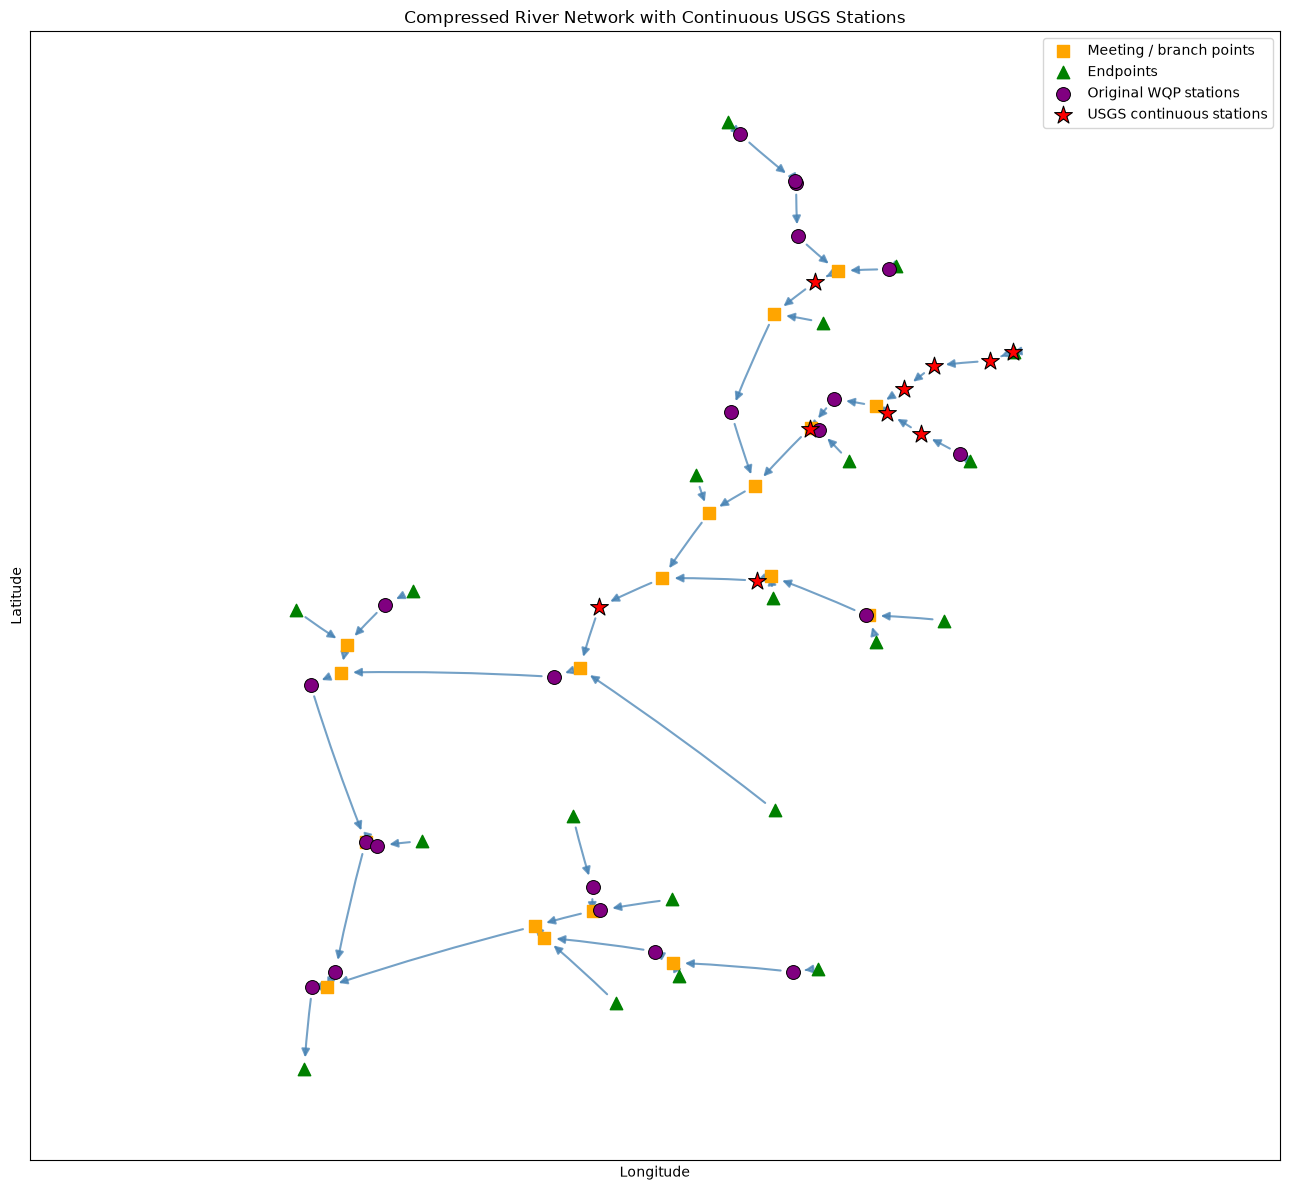

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
plt.figure(figsize=(13, 12))

# -----------------------------
# River edges
# -----------------------------

nx.draw_networkx_edges(
    G_compressed,
    pos,
    edge_color="steelblue",
    width=1.5,
    alpha=0.75,
    arrows=True,
    arrowsize=12,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=0.02"
)


# -----------------------------
# Other retained nodes
# -----------------------------

nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=other_nodes,
    node_size=35,
    node_color="gray",
    label="Other retained nodes"
)


# -----------------------------
# Meeting / confluence nodes
# -----------------------------

nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=meeting_nodes,
    node_size=80,
    node_color="orange",
    node_shape="s",
    label="Meeting / branch points"
)


# -----------------------------
# Endpoints
# -----------------------------

nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=endpoint_nodes,
    node_size=80,
    node_color="green",
    node_shape="^",
    label="Endpoints"
)


# -----------------------------
# Old WQP stations
# -----------------------------

nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=old_station_nodes,
    node_size=100,
    node_color="purple",
    node_shape="o",
    edgecolors="black",
    linewidths=0.7,
    label="Original WQP stations"
)


# -----------------------------
# New continuous USGS stations
# -----------------------------

nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=usgs_nodes,
    node_size=180,
    node_color="red",
    node_shape="*",
    edgecolors="black",
    linewidths=0.8,
    label="USGS continuous stations"
)


plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Compressed River Network with Continuous USGS Stations"
)

plt.legend()

plt.axis("equal")

plt.tight_layout()

plt.show()

In [ ]:
usgs_labels = {}

for node in usgs_nodes:

    stations = G_compressed.nodes[node].get(
        "usgs_stations",
        []
    )

    ids = [
        station["station_id"].replace(
            "USGS-",
            ""
        )
        for station in stations
    ]

    usgs_labels[node] = "\n".join(ids)

In [ ]:
wqp_fields = [
    "stations",
    "station_count",
    "station_ids",
    "station_id"
]

for node in G_largest.nodes():
    for field in wqp_fields:
        G_largest.nodes[node].pop(field, None)

print("Old WQP metadata removed from G_largest.")

Old WQP metadata removed from G_largest.


In [ ]:
print(
    "Remaining old WQP stations:",
    sum(
        data.get("station_count", 0)
        for _, data in G_largest.nodes(data=True)
    )
)

print(
    "USGS stations still attached:",
    sum(
        data.get("usgs_station_count", 0)
        for _, data in G_largest.nodes(data=True)
    )
)

Remaining old WQP stations: 0
USGS stations still attached: 10


In [ ]:
G_compressed = compress_river_graph(G_largest)

print("Compressed nodes:", G_compressed.number_of_nodes())
print("Compressed edges:", G_compressed.number_of_edges())
print("Directed:", G_compressed.is_directed())

print(
    "Weak components:",
    nx.number_weakly_connected_components(G_compressed)
)

print(
    "Old WQP stations in compressed graph:",
    sum(
        data.get("station_count", 0)
        for _, data in G_compressed.nodes(data=True)
    )
)

print(
    "USGS stations in compressed graph:",
    sum(
        data.get("usgs_station_count", 0)
        for _, data in G_compressed.nodes(data=True)
    )
)

Original nodes: 67401
Nodes retained: 48
Nodes compressed: 67353
Compressed nodes: 48
Compressed edges: 47
Directed: True
Weak components: 1
Old WQP stations in compressed graph: 0
USGS stations in compressed graph: 10


In [44]:
import pickle
import os

temp_file = "compressed_river_graph_usgs_only.tmp"
final_file = "compressed_river_graph_usgs_only.pkl"

with open(temp_file, "wb") as f:
    pickle.dump(
        G_compressed,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )

os.replace(temp_file, final_file)

print("Saved:", final_file)
print("File size:", os.path.getsize(final_file), "bytes")

NameError: name 'G_compressed' is not defined

In [ ]:
pos = {
    node: (
        data["longitude"],
        data["latitude"]
    )
    for node, data in G_compressed.nodes(data=True)
}

In [ ]:
usgs_nodes = []
endpoint_nodes = []
meeting_nodes = []
other_nodes = []

for node, data in G_compressed.nodes(data=True):

    total_degree = (
        G_compressed.in_degree(node)
        + G_compressed.out_degree(node)
    )

    if data.get("usgs_station_count", 0) > 0:
        usgs_nodes.append(node)

    elif total_degree == 1:
        endpoint_nodes.append(node)

    elif total_degree >= 3:
        meeting_nodes.append(node)

    else:
        other_nodes.append(node)

print("USGS station nodes:", len(usgs_nodes))
print("Endpoints:", len(endpoint_nodes))
print("Meeting points:", len(meeting_nodes))
print("Other retained nodes:", len(other_nodes))

USGS station nodes: 10
Endpoints: 20
Meeting points: 18
Other retained nodes: 0


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(13, 12))

# Edges
nx.draw_networkx_edges(
    G_compressed,
    pos,
    edge_color="steelblue",
    width=1.5,
    alpha=0.75,
    arrows=True,
    arrowsize=12,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=0.02"
)

# Other nodes
nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=other_nodes,
    node_size=35,
    node_color="gray",
    label="Other retained nodes"
)

# Meeting points
nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=meeting_nodes,
    node_size=80,
    node_color="orange",
    node_shape="s",
    label="Meeting / branch points"
)

# Endpoints
nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=endpoint_nodes,
    node_size=80,
    node_color="green",
    node_shape="^",
    label="Endpoints"
)

# USGS stations
nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=usgs_nodes,
    node_size=180,
    node_color="red",
    node_shape="*",
    edgecolors="black",
    linewidths=0.8,
    label="USGS continuous stations"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Compressed River Network with USGS Continuous Stations")
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.show()

NameError: name 'G_compressed' is not defined

<Figure size 1300x1200 with 0 Axes>

In [ ]:
graph_lats = [
    data["latitude"]
    for _, data in G_largest.nodes(data=True)
]

min_lat = min(graph_lats)
max_lat = max(graph_lats)

bottom_cutoff = (
    min_lat
    + (max_lat - min_lat) / 3
)

print("Minimum latitude:", min_lat)
print("Maximum latitude:", max_lat)
print("Bottom-third cutoff:", bottom_cutoff)

Minimum latitude: 31.8175
Maximum latitude: 42.1575
Bottom-third cutoff: 35.26416666666667


In [ ]:
station_coords = (
    usgs_sites[
        [
            "monitoring_location_id",
            "latitude",
            "longitude"
        ]
    ]
    .drop_duplicates(
        subset="monitoring_location_id"
    )
    .set_index("monitoring_location_id")
)

ranked_with_coords = ranked_sites.join(
    station_coords,
    how="left"
)

In [ ]:
bottom_stations = ranked_with_coords[
    ranked_with_coords["latitude"]
    <= bottom_cutoff
].copy()

print(
    "Continuous stations near river in bottom third:",
    len(bottom_stations)
)

print(
    bottom_stations[
        "core_count"
    ].value_counts().sort_index()
)

Continuous stations near river in bottom third: 45
core_count
0    39
2     4
4     2
Name: count, dtype: int64


In [ ]:
bottom_stations[
    [
        "DO concentration",
        "Water temperature",
        "Specific conductance",
        "Turbidity",
        "pH",
        "DO saturation",
        "Nitrate",
        "Stage",
        "Discharge",
        "core_count",
        "bonus_count",
        "has_hydrology",
        "distance_to_river_m",
        "latitude",
        "longitude"
    ]
].sort_values(
    [
        "core_count",
        "bonus_count",
        "has_hydrology"
    ],
    ascending=False
).head(30)

,DO concentration,Water temperature,Specific conductance,Turbidity,pH,DO saturation,Nitrate,Stage,Discharge,core_count,bonus_count,has_hydrology,distance_to_river_m,latitude,longitude
monitoring_location_id,,,,,,,,,,,,,,,
USGS-09510000,True,True,True,False,True,True,False,True,True,4,1,True,88.155093,33.808289,-111.661911
USGS-09429490,True,True,True,False,True,True,False,False,False,4,1,False,98.629570,32.884936,-114.468111
USGS-09426630,False,True,False,True,False,False,False,False,False,2,0,False,3.937847,34.293417,-114.081806
USGS-332106112314101,False,True,True,False,False,False,False,False,False,2,0,False,26.709524,33.351683,-112.528044
USGS-09522005,False,True,True,False,False,False,False,False,False,2,0,False,39.736556,32.712222,-114.722222
USGS-331954112371801,False,True,True,False,False,False,False,False,False,2,0,False,83.432878,33.331753,-112.621656
USGS-09498500,False,False,False,False,False,False,False,True,True,0,0,True,0.000084,33.619167,-110.922083
USGS-09519800,False,False,False,False,False,False,False,True,True,0,0,True,2.179878,33.078108,-113.018078
USGS-09520360,False,False,False,False,False,False,False,False,True,0,0,True,5.173629,32.788380,-113.764092


In [ ]:
bottom_near_complete = bottom_stations[
    (bottom_stations["core_count"] >= 4)
    &
    (bottom_stations["has_hydrology"])
].copy()

print(
    "Bottom stations with >=4/5 core variables + hydrology:",
    len(bottom_near_complete)
)

bottom_near_complete[
    [
        "DO concentration",
        "Water temperature",
        "Specific conductance",
        "Turbidity",
        "pH",
        "Stage",
        "Discharge",
        "core_count",
        "distance_to_river_m",
        "latitude"
    ]
].sort_values(
    "core_count",
    ascending=False
)

Bottom stations with >=4/5 core variables + hydrology: 1


,DO concentration,Water temperature,Specific conductance,Turbidity,pH,Stage,Discharge,core_count,distance_to_river_m,latitude
monitoring_location_id,,,,,,,,,,
USGS-09510000,True,True,True,False,True,True,True,4,88.155093,33.808289


In [ ]:
bottom_250 = usgs_edge_matches[
    (
        usgs_edge_matches["latitude"]
        <= bottom_cutoff
    )
    &
    (
        usgs_edge_matches["distance_to_river_m"]
        <= 250
    )
].copy()

print(
    "Bottom flowing stations within 250 m:",
    bottom_250[
        "monitoring_location_id"
    ].nunique()
)

Bottom flowing stations within 250 m: 58


In [ ]:
for distance in [100, 150, 200, 250, 500]:

    count = (
        usgs_edge_matches[
            (
                usgs_edge_matches["latitude"]
                <= bottom_cutoff
            )
            &
            (
                usgs_edge_matches["distance_to_river_m"]
                <= distance
            )
        ]["monitoring_location_id"]
        .nunique()
    )

    print(
        f"Bottom third within {distance} m: "
        f"{count}"
    )

Bottom third within 100 m: 45
Bottom third within 150 m: 51
Bottom third within 200 m: 56
Bottom third within 250 m: 58
Bottom third within 500 m: 72


In [ ]:
bottom_250_ids = set(
    bottom_250[
        "monitoring_location_id"
    ]
)

bottom_availability = ranked_with_coords[
    ranked_with_coords.index.isin(
        bottom_250_ids
    )
].copy()

print(
    "Bottom stations:",
    len(bottom_availability)
)

Bottom stations: 45


In [ ]:
for variable in CORE_VARIABLES:

    count = bottom_availability[
        variable
    ].sum()

    print(
        f"{variable:25s}: "
        f"{count:>3} / {len(bottom_availability)}"
    )

DO concentration         :   2 / 45
Water temperature        :   6 / 45
Specific conductance     :   5 / 45
Turbidity                :   1 / 45
pH                       :   2 / 45


In [ ]:
print(
    "Hydrology:",
    bottom_availability[
        "has_hydrology"
    ].sum(),
    "/",
    len(bottom_availability)
)

Hydrology: 40 / 45


In [ ]:
print(
    bottom_availability[
        "core_count"
    ]
    .value_counts()
    .sort_index()
)

core_count
0    39
2     4
4     2
Name: count, dtype: int64


In [ ]:
bottom_availability[
    [
        "DO concentration",
        "Water temperature",
        "Specific conductance",
        "Turbidity",
        "pH",
        "Stage",
        "Discharge",
        "core_count",
        "has_hydrology",
        "distance_to_river_m",
        "latitude"
    ]
].sort_values(
    [
        "core_count",
        "has_hydrology"
    ],
    ascending=False
).head(25)

,DO concentration,Water temperature,Specific conductance,Turbidity,pH,Stage,Discharge,core_count,has_hydrology,distance_to_river_m,latitude
monitoring_location_id,,,,,,,,,,,
USGS-09510000,True,True,True,False,True,True,True,4,True,88.155093,33.808289
USGS-09429490,True,True,True,False,True,False,False,4,False,98.629570,32.884936
USGS-09426630,False,True,False,True,False,False,False,2,False,3.937847,34.293417
USGS-332106112314101,False,True,True,False,False,False,False,2,False,26.709524,33.351683
USGS-09522005,False,True,True,False,False,False,False,2,False,39.736556,32.712222
USGS-331954112371801,False,True,True,False,False,False,False,2,False,83.432878,33.331753
USGS-09498500,False,False,False,False,False,True,True,0,True,0.000084,33.619167
USGS-09519800,False,False,False,False,False,True,True,0,True,2.179878,33.078108
USGS-09520360,False,False,False,False,False,False,True,0,True,5.173629,32.788380


In [ ]:
bottom_250_ids = set(
    bottom_250[
        "monitoring_location_id"
    ].astype(str)
)

print(
    "Bottom stations within 250 m:",
    len(bottom_250_ids)
)

Bottom stations within 250 m: 58


In [ ]:
bottom_250_metadata = flowing_metadata[
    flowing_metadata[
        "monitoring_location_id"
    ].astype(str).isin(
        bottom_250_ids
    )
].copy()

print(
    "Stations represented in metadata:",
    bottom_250_metadata[
        "monitoring_location_id"
    ].nunique()
)

Stations represented in metadata: 58


In [ ]:
bottom_250_availability = pd.crosstab(
    bottom_250_metadata[
        "monitoring_location_id"
    ],
    bottom_250_metadata[
        "variable"
    ]
).gt(0)

In [ ]:
ALL_VARIABLES = [
    "DO concentration",
    "DO saturation",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH",
    "Nitrate",
    "Chlorophyll-a",
    "fDOM/CDOM",
    "Stage",
    "Discharge"
]

for variable in ALL_VARIABLES:
    if variable not in bottom_250_availability.columns:
        bottom_250_availability[variable] = False

In [ ]:
bottom_250_availability["core_count"] = (
    bottom_250_availability[
        CORE_VARIABLES
    ].sum(axis=1)
)

bottom_250_availability["has_hydrology"] = (
    bottom_250_availability["Stage"]
    |
    bottom_250_availability["Discharge"]
)

In [ ]:
bottom_info = (
    bottom_250[
        [
            "monitoring_location_id",
            "distance_to_river_m",
            "latitude",
            "longitude"
        ]
    ]
    .drop_duplicates(
        subset="monitoring_location_id"
    )
    .set_index(
        "monitoring_location_id"
    )
)

bottom_250_availability = (
    bottom_250_availability
    .join(
        bottom_info,
        how="left"
    )
)

In [ ]:
bottom_250_ranked = (
    bottom_250_availability
    .sort_values(
        [
            "core_count",
            "has_hydrology",
            "distance_to_river_m"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
)

bottom_250_ranked[
    [
        "DO concentration",
        "Water temperature",
        "Specific conductance",
        "Turbidity",
        "pH",
        "Stage",
        "Discharge",
        "core_count",
        "has_hydrology",
        "distance_to_river_m",
        "latitude"
    ]
].head(30)

,DO concentration,Water temperature,Specific conductance,Turbidity,pH,Stage,Discharge,core_count,has_hydrology,distance_to_river_m,latitude
monitoring_location_id,,,,,,,,,,,
USGS-09510000,True,True,True,False,True,True,True,4,True,88.155093,33.808289
USGS-09429490,True,True,True,False,True,False,False,4,False,98.629570,32.884936
USGS-09426630,False,True,False,True,False,False,False,2,False,3.937847,34.293417
USGS-332106112314101,False,True,True,False,False,False,False,2,False,26.709524,33.351683
USGS-09522005,False,True,True,False,False,False,False,2,False,39.736556,32.712222
USGS-331954112371801,False,True,True,False,False,False,False,2,False,83.432878,33.331753
USGS-332029112353701,False,True,True,False,False,False,False,2,False,169.349124,33.341517
USGS-09498500,False,False,False,False,False,True,True,0,True,0.000084,33.619167
USGS-09519800,False,False,False,False,False,True,True,0,True,2.179878,33.078108


In [ ]:
print(
    "Stations:",
    len(bottom_250_ranked)
)

for variable in CORE_VARIABLES:

    print(
        f"{variable:25s}: "
        f"{bottom_250_ranked[variable].sum():>3} / "
        f"{len(bottom_250_ranked)}"
    )

print(
    "\nHydrology:",
    bottom_250_ranked[
        "has_hydrology"
    ].sum(),
    "/",
    len(bottom_250_ranked)
)

print("\nCore-count distribution:")

print(
    bottom_250_ranked[
        "core_count"
    ]
    .value_counts()
    .sort_index()
)

Stations: 58
DO concentration         :   2 / 58
Water temperature        :   7 / 58
Specific conductance     :   6 / 58
Turbidity                :   1 / 58
pH                       :   2 / 58

Hydrology: 52 / 58

Core-count distribution:
core_count
0    51
2     5
4     2
Name: count, dtype: int64


In [ ]:
extra_sites = [
    "USGS-09510000"
]

expanded_ml_sites = sorted(
    set(ml_ready_sites + extra_sites)
)

print("Original ML sites:", len(ml_ready_sites))
print("Expanded sites:", len(expanded_ml_sites))

for site in expanded_ml_sites:
    print(site)

Original ML sites: 10
Expanded sites: 11
USGS-09070500
USGS-09092570
USGS-09095500
USGS-09144250
USGS-09152500
USGS-09180500
USGS-09261000
USGS-09379500
USGS-09380000
USGS-09510000
USGS-393259107194801


In [ ]:
bottom_250_ranked.loc[
    ["USGS-09510000"]
]

,DO concentration,DO saturation,Discharge,Specific conductance,Stage,Turbidity,Water temperature,pH,Nitrate,Chlorophyll-a,fDOM/CDOM,core_count,has_hydrology,distance_to_river_m,latitude,longitude
monitoring_location_id,,,,,,,,,,,,,,,,
USGS-09510000,True,True,True,True,True,False,True,True,False,False,False,4,True,88.155093,33.808289,-111.661911


In [ ]:
LOWER_CORE = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "pH"
]

In [ ]:
all_250 = (
    usgs_edge_matches[
        usgs_edge_matches[
            "distance_to_river_m"
        ] <= 250
    ]
    .copy()
)

all_250 = (
    all_250
    .sort_values("distance_to_river_m")
    .drop_duplicates(
        subset="monitoring_location_id"
    )
)

print(
    "Flowing-water stations within 250 m:",
    all_250[
        "monitoring_location_id"
    ].nunique()
)

Flowing-water stations within 250 m: 149


In [ ]:
all_250_ids = set(
    all_250[
        "monitoring_location_id"
    ].astype(str)
)

all_250_metadata = flowing_metadata[
    flowing_metadata[
        "monitoring_location_id"
    ]
    .astype(str)
    .isin(all_250_ids)
].copy()

print(
    "Stations represented:",
    all_250_metadata[
        "monitoring_location_id"
    ].nunique()
)

Stations represented: 149


In [ ]:
all_250_availability = pd.crosstab(
    all_250_metadata[
        "monitoring_location_id"
    ],
    all_250_metadata[
        "variable"
    ]
).gt(0)

In [ ]:
ALL_VARIABLES = [
    "DO concentration",
    "DO saturation",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH",
    "Nitrate",
    "Chlorophyll-a",
    "fDOM/CDOM",
    "Stage",
    "Discharge"
]

for variable in ALL_VARIABLES:

    if variable not in all_250_availability.columns:
        all_250_availability[variable] = False

In [ ]:
CORE_VARIABLES = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]

all_250_availability["core_count"] = (
    all_250_availability[
        CORE_VARIABLES
    ].sum(axis=1)
)

all_250_availability["has_hydrology"] = (
    all_250_availability["Stage"]
    |
    all_250_availability["Discharge"]
)

In [ ]:
all_station_info = (
    all_250[
        [
            "monitoring_location_id",
            "distance_to_river_m",
            "latitude",
            "longitude"
        ]
    ]
    .drop_duplicates(
        subset="monitoring_location_id"
    )
    .set_index(
        "monitoring_location_id"
    )
)

all_250_availability = (
    all_250_availability
    .join(
        all_station_info,
        how="left"
    )
)

In [ ]:
graph_lats = [
    data["latitude"]
    for _, data
    in G_largest.nodes(data=True)
]

min_lat = min(graph_lats)
max_lat = max(graph_lats)

half_latitude = (
    min_lat + max_lat
) / 2

print("Bottom:", min_lat)
print("Midpoint:", half_latitude)
print("Top:", max_lat)

Bottom: 31.8175
Midpoint: 36.9875
Top: 42.1575


In [ ]:
all_250_availability["region"] = np.where(
    all_250_availability["latitude"]
    >= half_latitude,
    "Top half",
    "Bottom half"
)

In [ ]:
print(
    all_250_availability[
        "region"
    ].value_counts()
)

region
Bottom half    105
Top half        44
Name: count, dtype: int64


In [ ]:
def classify_station(row):

    core = row["core_count"]
    hydro = row["has_hydrology"]

    if core == 5 and hydro:
        return "Tier A - 5/5 + hydrology"

    elif core == 4 and hydro:
        return "Tier B - 4/5 + hydrology"

    elif core >= 4 and not hydro:
        return "Tier C - 4+/5 no hydrology"

    elif 2 <= core <= 3 and hydro:
        return "Tier D - partial WQ + hydrology"

    elif core == 0 and hydro:
        return "Hydrology support"

    elif core > 0:
        return "Other WQ"

    else:
        return "Low value"


all_250_availability["station_class"] = (
    all_250_availability.apply(
        classify_station,
        axis=1
    )
)

In [ ]:
pd.crosstab(
    all_250_availability["region"],
    all_250_availability["station_class"]
)

station_class,Hydrology support,Other WQ,Tier A - 5/5 + hydrology,Tier B - 4/5 + hydrology,Tier C - 4+/5 no hydrology,Tier D - partial WQ + hydrology
region,,,,,,
Bottom half,72,27,1,3,1,1
Top half,17,5,12,1,3,6


In [ ]:
top_candidates = (
    all_250_availability[
        all_250_availability[
            "region"
        ] == "Top half"
    ]
    .sort_values(
        [
            "core_count",
            "has_hydrology",
            "distance_to_river_m"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
)

top_candidates[
    [
        "DO concentration",
        "Water temperature",
        "Specific conductance",
        "Turbidity",
        "pH",
        "Stage",
        "Discharge",
        "core_count",
        "has_hydrology",
        "station_class",
        "distance_to_river_m"
    ]
].head(30)

,DO concentration,Water temperature,Specific conductance,Turbidity,pH,Stage,Discharge,core_count,has_hydrology,station_class,distance_to_river_m
monitoring_location_id,,,,,,,,,,,
USGS-09092570,True,True,True,True,True,True,True,5,True,Tier A - 5/5 + hydrology,3.318171e-07
USGS-09095500,True,True,True,True,True,True,True,5,True,Tier A - 5/5 + hydrology,2.281560e+00
USGS-09379500,True,True,True,True,True,True,True,5,True,Tier A - 5/5 + hydrology,1.230243e+01
USGS-09152500,True,True,True,True,True,True,True,5,True,Tier A - 5/5 + hydrology,1.631311e+01
USGS-09144250,True,True,True,True,True,True,True,5,True,Tier A - 5/5 + hydrology,2.482770e+01
USGS-09070500,True,True,True,True,True,True,True,5,True,Tier A - 5/5 + hydrology,4.980609e+01
USGS-393259107194801,True,True,True,True,True,True,False,5,True,Tier A - 5/5 + hydrology,6.244569e+01
USGS-09180500,True,True,True,True,True,True,True,5,True,Tier A - 5/5 + hydrology,6.890534e+01
USGS-09261000,True,True,True,True,True,True,True,5,True,Tier A - 5/5 + hydrology,8.998377e+01


In [ ]:
bottom_candidates = (
    all_250_availability[
        all_250_availability[
            "region"
        ] == "Bottom half"
    ]
    .sort_values(
        [
            "core_count",
            "has_hydrology",
            "distance_to_river_m"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
)

bottom_candidates[
    [
        "DO concentration",
        "Water temperature",
        "Specific conductance",
        "Turbidity",
        "pH",
        "Stage",
        "Discharge",
        "core_count",
        "has_hydrology",
        "station_class",
        "distance_to_river_m"
    ]
].head(30)

,DO concentration,Water temperature,Specific conductance,Turbidity,pH,Stage,Discharge,core_count,has_hydrology,station_class,distance_to_river_m
monitoring_location_id,,,,,,,,,,,
USGS-09380000,True,True,True,True,True,True,True,5,True,Tier A - 5/5 + hydrology,74.694619
USGS-09368000,False,True,True,True,True,True,True,4,True,Tier B - 4/5 + hydrology,19.280541
USGS-09365000,False,True,True,True,True,True,True,4,True,Tier B - 4/5 + hydrology,52.109066
USGS-09510000,True,True,True,False,True,True,True,4,True,Tier B - 4/5 + hydrology,88.155093
USGS-09429490,True,True,True,False,True,False,False,4,False,Tier C - 4+/5 no hydrology,98.629570
USGS-09404200,False,True,True,False,False,True,True,2,True,Tier D - partial WQ + hydrology,29.792825
USGS-09426630,False,True,False,True,False,False,False,2,False,Other WQ,3.937847
USGS-332106112314101,False,True,True,False,False,False,False,2,False,Other WQ,26.709524
USGS-09522005,False,True,True,False,False,False,False,2,False,Other WQ,39.736556


In [ ]:
for region in [
    "Top half",
    "Bottom half"
]:

    subset = all_250_availability[
        all_250_availability[
            "region"
        ] == region
    ]

    print("\n" + "=" * 50)
    print(region)
    print("Stations:", len(subset))

    for variable in CORE_VARIABLES:

        print(
            f"{variable:25s}: "
            f"{subset[variable].sum():>3} / "
            f"{len(subset)}"
        )

    print(
        f"{'Hydrology':25s}: "
        f"{subset['has_hydrology'].sum():>3} / "
        f"{len(subset)}"
    )


Top half
Stations: 44
DO concentration         :  16 / 44
Water temperature        :  27 / 44
Specific conductance     :  22 / 44
Turbidity                :  17 / 44
pH                       :  16 / 44
Hydrology                :  39 / 44

Bottom half
Stations: 105
DO concentration         :   3 / 105
Water temperature        :  31 / 105
Specific conductance     :  10 / 105
Turbidity                :   6 / 105
pH                       :   5 / 105
Hydrology                :  83 / 105


In [ ]:
WQ_CLASSES_TO_KEEP = [
    "Tier A - 5/5 + hydrology",
    "Tier B - 4/5 + hydrology",
    "Tier C - 4+/5 no hydrology",
    "Tier D - partial WQ + hydrology"
]

selected_wq_stations = (
    all_250_availability[
        all_250_availability[
            "station_class"
        ].isin(WQ_CLASSES_TO_KEEP)
    ]
    .copy()
)

print(
    "Selected WQ stations:",
    len(selected_wq_stations)
)

print(
    selected_wq_stations[
        "region"
    ].value_counts()
)

Selected WQ stations: 28
region
Top half       22
Bottom half     6
Name: count, dtype: int64


In [ ]:
hydrology_support = (
    all_250_availability[
        all_250_availability[
            "station_class"
        ] == "Hydrology support"
    ]
    .copy()
)

print(
    "Hydrology-only support gauges:",
    len(hydrology_support)
)

Hydrology-only support gauges: 89


In [ ]:
for node in G_largest.nodes():

    G_largest.nodes[node].pop(
        "usgs_stations",
        None
    )

    G_largest.nodes[node].pop(
        "usgs_station_count",
        None
    )

print("Old USGS station metadata cleared.")

Old USGS station metadata cleared.


In [ ]:
selected_ids = set(
    selected_wq_stations.index.astype(str)
)

print(
    "Selected stations:",
    len(selected_ids)
)

Selected stations: 28


In [ ]:
selected_points = (
    usgs_sites_gdf[
        usgs_sites_gdf[
            "monitoring_location_id"
        ]
        .astype(str)
        .isin(selected_ids)
    ]
    .copy()
)

print(
    "Station points found:",
    selected_points[
        "monitoring_location_id"
    ].nunique()
)

Station points found: 28


In [ ]:
selected_points_m = (
    selected_points
    .to_crs("EPSG:5070")
)

In [ ]:
selected_node_matches = (
    gpd.sjoin_nearest(
        selected_points_m,
        river_nodes_m,
        how="left",
        distance_col="distance_to_node_m"
    )
)

selected_node_matches = (
    selected_node_matches
    .sort_values("distance_to_node_m")
    .drop_duplicates(
        subset="monitoring_location_id"
    )
    .reset_index(drop=True)
)

print(
    "Stations matched:",
    selected_node_matches[
        "monitoring_location_id"
    ].nunique()
)

print(
    "Farthest station-to-node distance:",
    selected_node_matches[
        "distance_to_node_m"
    ].max(),
    "m"
)

Stations matched: 28
Farthest station-to-node distance: 199.80598486798053 m


In [ ]:
for node in G_largest.nodes():

    G_largest.nodes[node][
        "usgs_stations"
    ] = []

    G_largest.nodes[node][
        "usgs_station_count"
    ] = 0

In [ ]:
for _, match in selected_node_matches.iterrows():

    station_id = str(
        match["monitoring_location_id"]
    )

    node = int(
        match["river_node"]
    )

    info = selected_wq_stations.loc[
        station_id
    ]

    available_variables = [
        variable
        for variable in CORE_VARIABLES
        if bool(info[variable])
    ]

    station_data = {
        "station_id": station_id,

        "station_class": str(
            info["station_class"]
        ),

        "region": str(
            info["region"]
        ),

        "core_count": int(
            info["core_count"]
        ),

        "has_hydrology": bool(
            info["has_hydrology"]
        ),

        "available_core_variables":
            available_variables,

        "distance_to_river_m": float(
            info["distance_to_river_m"]
        ),

        "distance_to_node_m": float(
            match["distance_to_node_m"]
        ),

        "latitude": float(
            info["latitude"]
        ),

        "longitude": float(
            info["longitude"]
        )
    }

    G_largest.nodes[node][
        "usgs_stations"
    ].append(
        station_data
    )

    G_largest.nodes[node][
        "usgs_station_count"
    ] += 1

In [ ]:
print(
    "Stations attached:",
    sum(
        data.get(
            "usgs_station_count",
            0
        )
        for _, data
        in G_largest.nodes(data=True)
    )
)

print(
    "Nodes with stations:",
    sum(
        data.get(
            "usgs_station_count",
            0
        ) > 0
        for _, data
        in G_largest.nodes(data=True)
    )
)

Stations attached: 28
Nodes with stations: 28


In [ ]:
G_compressed = compress_river_graph(
    G_largest
)

print("Nodes:", G_compressed.number_of_nodes())
print("Edges:", G_compressed.number_of_edges())

print(
    "Weak components:",
    nx.number_weakly_connected_components(
        G_compressed
    )
)

print(
    "Selected USGS stations:",
    sum(
        d.get(
            "usgs_station_count",
            0
        )
        for _, d
        in G_compressed.nodes(data=True)
    )
)

Original nodes: 67401
Nodes retained: 66
Nodes compressed: 67335
Nodes: 66
Edges: 65
Weak components: 1
Selected USGS stations: 28


In [ ]:
pos = {
    node: (
        data["longitude"],
        data["latitude"]
    )
    for node, data in G_compressed.nodes(data=True)
}

In [ ]:
tier_a_nodes = []
tier_b_nodes = []
tier_c_nodes = []
tier_d_nodes = []

endpoint_nodes = []
meeting_nodes = []
other_nodes = []

for node, data in G_compressed.nodes(data=True):

    total_degree = (
        G_compressed.in_degree(node)
        + G_compressed.out_degree(node)
    )

    stations = data.get("usgs_stations", [])

    if len(stations) > 0:
        classes = {
            station["station_class"]
            for station in stations
        }

        if "Tier A - 5/5 + hydrology" in classes:
            tier_a_nodes.append(node)

        elif "Tier B - 4/5 + hydrology" in classes:
            tier_b_nodes.append(node)

        elif "Tier C - 4+/5 no hydrology" in classes:
            tier_c_nodes.append(node)

        elif "Tier D - partial WQ + hydrology" in classes:
            tier_d_nodes.append(node)

    elif total_degree == 1:
        endpoint_nodes.append(node)

    elif total_degree >= 3:
        meeting_nodes.append(node)

    else:
        other_nodes.append(node)

In [ ]:
print("Tier A nodes:", len(tier_a_nodes))
print("Tier B nodes:", len(tier_b_nodes))
print("Tier C nodes:", len(tier_c_nodes))
print("Tier D nodes:", len(tier_d_nodes))
print("Meeting nodes:", len(meeting_nodes))
print("Endpoint nodes:", len(endpoint_nodes))
print("Other nodes:", len(other_nodes))

Tier A nodes: 13
Tier B nodes: 4
Tier C nodes: 4
Tier D nodes: 7
Meeting nodes: 18
Endpoint nodes: 20
Other nodes: 0


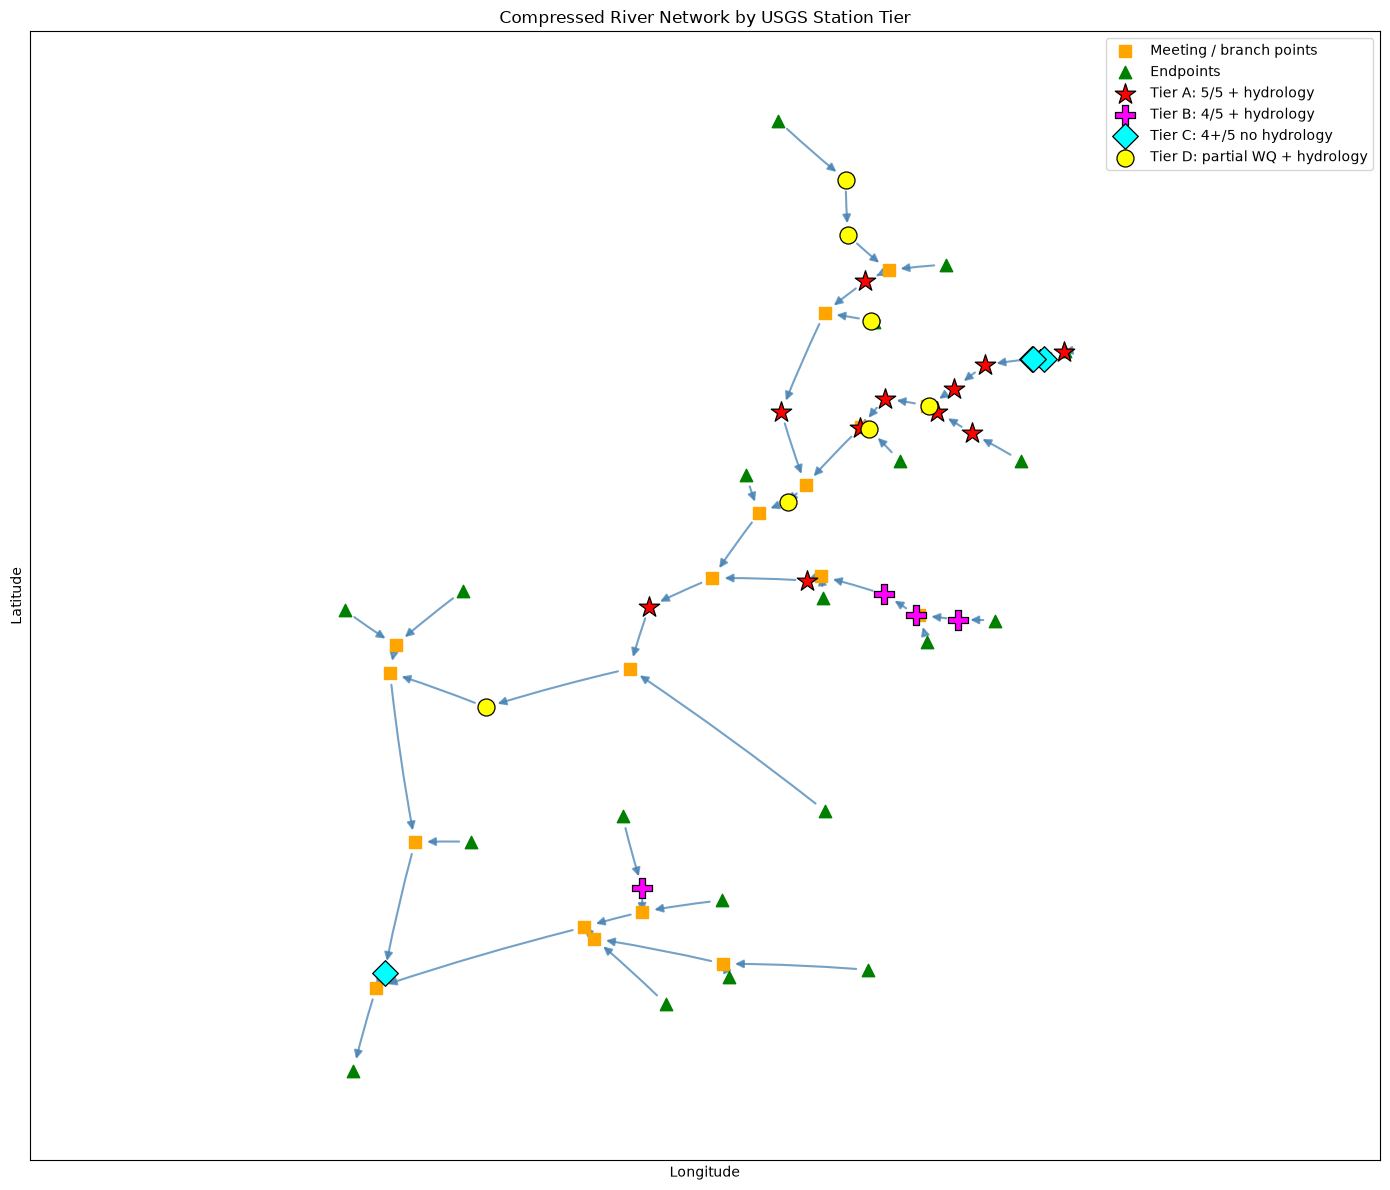

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(14, 12))

# River edges
nx.draw_networkx_edges(
    G_compressed,
    pos,
    edge_color="steelblue",
    width=1.5,
    alpha=0.75,
    arrows=True,
    arrowsize=12,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=0.02"
)

# Other retained nodes
nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=other_nodes,
    node_size=30,
    node_color="gray",
    label="Other retained nodes"
)

# Meeting / branch points
nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=meeting_nodes,
    node_size=80,
    node_color="orange",
    node_shape="s",
    label="Meeting / branch points"
)

# Endpoints
nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=endpoint_nodes,
    node_size=80,
    node_color="green",
    node_shape="^",
    label="Endpoints"
)

# Tier A
nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=tier_a_nodes,
    node_size=240,
    node_color="red",
    node_shape="*",
    edgecolors="black",
    linewidths=0.9,
    label="Tier A: 5/5 + hydrology"
)

# Tier B
nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=tier_b_nodes,
    node_size=190,
    node_color="magenta",
    node_shape="P",
    edgecolors="black",
    linewidths=0.9,
    label="Tier B: 4/5 + hydrology"
)

# Tier C
nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=tier_c_nodes,
    node_size=170,
    node_color="cyan",
    node_shape="D",
    edgecolors="black",
    linewidths=0.9,
    label="Tier C: 4+/5 no hydrology"
)

# Tier D
nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=tier_d_nodes,
    node_size=150,
    node_color="yellow",
    node_shape="o",
    edgecolors="black",
    linewidths=0.9,
    label="Tier D: partial WQ + hydrology"
)

plt.title("Compressed River Network by USGS Station Tier")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("equal")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(
    "compressed_river_network_by_tier.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
downloaded_sites = set(ml_ready_sites)

selected_sites = set(
    selected_wq_stations.index.astype(str)
)

new_wq_sites = sorted(
    selected_sites - downloaded_sites
)

print("Already downloaded:", len(downloaded_sites))
print("Selected total:", len(selected_sites))
print("New stations to download:", len(new_wq_sites))

for site in new_wq_sites:
    print(site)

Already downloaded: 10
Selected total: 28
New stations to download: 18
USGS-09071750
USGS-09085000
USGS-09085150
USGS-09085160
USGS-09106485
USGS-09163500
USGS-09180000
USGS-09217000
USGS-09234500
USGS-09306500
USGS-09315000
USGS-09328960
USGS-09365000
USGS-09368000
USGS-09371010
USGS-09404200
USGS-09429490
USGS-09510000


In [ ]:
VARIABLE_PCODES = {
    "DO concentration": "00300",
    "Water temperature": "00010",
    "Specific conductance": "00095",
    "Turbidity": "63680",
    "pH": "00400",
    "Discharge": "00060",
    "Stage": "00065"
}

In [ ]:
site_id = new_wq_sites[0]

row = selected_wq_stations.loc[site_id]

available = [
    variable
    for variable in VARIABLE_PCODES
    if variable in row.index
    and bool(row[variable])
]

print(site_id)
print(available)

USGS-09071750
['DO concentration', 'Water temperature', 'Specific conductance', 'Turbidity', 'pH']


In [ ]:
support_gauge_ids = set(
    hydrology_support.index.astype(str)
)

print(
    "Potential hydrology support gauges:",
    len(support_gauge_ids)
)

Potential hydrology support gauges: 89


In [ ]:
support_ids = set(
    hydrology_support.index.astype(str)
)

support_points = (
    usgs_sites_gdf[
        usgs_sites_gdf[
            "monitoring_location_id"
        ].astype(str).isin(support_ids)
    ]
    .copy()
)

print(
    "Support gauges found:",
    support_points[
        "monitoring_location_id"
    ].nunique()
)

Support gauges found: 89


In [ ]:
support_points_m = (
    support_points
    .to_crs("EPSG:5070")
)

In [ ]:
support_node_matches = gpd.sjoin_nearest(
    support_points_m,
    river_nodes_m,
    how="left",
    distance_col="distance_to_node_m"
)

support_node_matches = (
    support_node_matches
    .sort_values("distance_to_node_m")
    .drop_duplicates(
        subset="monitoring_location_id"
    )
    .reset_index(drop=True)
)

print(
    "Support gauges matched:",
    support_node_matches[
        "monitoring_location_id"
    ].nunique()
)

Support gauges matched: 89


In [ ]:
support_node_matches[
    "distance_to_node_m"
].describe()

count     89.000000
mean      71.382269
std       48.152254
min        5.023746
25%       39.603012
50%       60.480457
75%       92.005317
max      251.298161
Name: distance_to_node_m, dtype: float64

In [ ]:
import math

def node_distance_m(G, u, v):

    lat1 = math.radians(
        G.nodes[u]["latitude"]
    )

    lon1 = math.radians(
        G.nodes[u]["longitude"]
    )

    lat2 = math.radians(
        G.nodes[v]["latitude"]
    )

    lon2 = math.radians(
        G.nodes[v]["longitude"]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        math.sin(dlat / 2) ** 2
        +
        math.cos(lat1)
        * math.cos(lat2)
        * math.sin(dlon / 2) ** 2
    )

    return (
        6371000
        * 2
        * math.atan2(
            math.sqrt(a),
            math.sqrt(1 - a)
        )
    )

In [ ]:
for u, v in G_largest.edges():

    G_largest.edges[u, v][
        "length_m"
    ] = node_distance_m(
        G_largest,
        u,
        v
    )

print("Edge distances added.")

Edge distances added.


In [ ]:
wq_node_lookup = {
    str(row["monitoring_location_id"]):
    int(row["river_node"])

    for _, row
    in selected_node_matches.iterrows()
}

In [ ]:
support_node_lookup = {
    str(row["monitoring_location_id"]):
    int(row["river_node"])

    for _, row
    in support_node_matches.iterrows()
}

In [ ]:
node_to_support = {}

for station_id, node in support_node_lookup.items():

    node_to_support.setdefault(
        node,
        []
    ).append(station_id)

In [ ]:
G_reverse = G_largest.reverse(
    copy=False
)

In [ ]:
import networkx as nx

def nearest_support_gauge(
    start_node,
    graph,
    node_to_support
):

    distances = nx.single_source_dijkstra_path_length(
        graph,
        start_node,
        weight="length_m"
    )

    best_station = None
    best_node = None
    best_distance = float("inf")

    for node, distance in distances.items():

        if node not in node_to_support:
            continue

        if distance < best_distance:

            best_distance = distance
            best_node = node

            best_station = (
                node_to_support[node][0]
            )

    if best_station is None:
        return None

    return {
        "station": best_station,
        "river_node": best_node,
        "distance_m": best_distance
    }

In [ ]:
support_results = []

for wq_station, wq_node in wq_node_lookup.items():

    upstream = nearest_support_gauge(
        wq_node,
        G_reverse,
        node_to_support
    )

    downstream = nearest_support_gauge(
        wq_node,
        G_largest,
        node_to_support
    )

    support_results.append({
        "wq_station": wq_station,

        "upstream_gauge": (
            upstream["station"]
            if upstream
            else None
        ),

        "upstream_distance_km": (
            upstream["distance_m"] / 1000
            if upstream
            else None
        ),

        "downstream_gauge": (
            downstream["station"]
            if downstream
            else None
        ),

        "downstream_distance_km": (
            downstream["distance_m"] / 1000
            if downstream
            else None
        )
    })

In [ ]:
support_table = pd.DataFrame(
    support_results
)

support_table

,wq_station,upstream_gauge,upstream_distance_km,downstream_gauge,downstream_distance_km
0,USGS-09085150,USGS-09085100,7.208353,USGS-09085500,4.206340
1,USGS-09092570,USGS-09085500,57.217498,USGS-09093700,30.530605
2,USGS-09152500,USGS-09151500,47.957685,USGS-09185600,237.698184
3,USGS-09379500,USGS-09379250,33.376487,USGS-09379700,103.198381
4,USGS-09328960,USGS-09185600,114.595478,USGS-09328990,45.574857
5,USGS-09368000,USGS-09367958,6.095376,USGS-09379700,299.674471
6,USGS-09095500,USGS-09093700,22.425348,USGS-09106150,25.414850
7,USGS-09144250,USGS-09128000,78.027545,USGS-09151500,25.168090
8,USGS-09234500,NaN,NaN,USGS-09272400,276.308098
9,USGS-09404200,USGS-09404120,99.292635,USGS-09421500,220.565007


In [ ]:
support_table.sort_values(
    "wq_station"
)

,wq_station,upstream_gauge,upstream_distance_km,downstream_gauge,downstream_distance_km
15,USGS-09070500,NaN,NaN,USGS-09085100,32.060633
21,USGS-09071750,NaN,NaN,USGS-09085100,6.414474
27,USGS-09085000,NaN,NaN,USGS-09085100,1.148829
0,USGS-09085150,USGS-09085100,7.208353,USGS-09085500,4.206340
10,USGS-09085160,USGS-09085100,8.319270,USGS-09085500,3.095422
1,USGS-09092570,USGS-09085500,57.217498,USGS-09093700,30.530605
6,USGS-09095500,USGS-09093700,22.425348,USGS-09106150,25.414850
14,USGS-09106485,USGS-09106150,22.999230,USGS-09185600,216.663342
7,USGS-09144250,USGS-09128000,78.027545,USGS-09151500,25.168090
2,USGS-09152500,USGS-09151500,47.957685,USGS-09185600,237.698184


In [ ]:
needed_support_gauges = set(
    support_table[
        "upstream_gauge"
    ].dropna()
).union(
    set(
        support_table[
            "downstream_gauge"
        ].dropna()
    )
)

print(
    "Potential hydrology gauges:",
    len(support_ids)
)

print(
    "Actually needed upstream/downstream gauges:",
    len(needed_support_gauges)
)

for gauge in sorted(
    needed_support_gauges
):
    print(gauge)

Potential hydrology gauges: 89
Actually needed upstream/downstream gauges: 25
USGS-09085100
USGS-09085500
USGS-09093700
USGS-09106150
USGS-09128000
USGS-09151500
USGS-09179450
USGS-09185600
USGS-09260000
USGS-09272400
USGS-09314700
USGS-09328920
USGS-09328990
USGS-09357700
USGS-09367958
USGS-09379250
USGS-09379700
USGS-09379910
USGS-09402500
USGS-09404120
USGS-09421500
USGS-09429300
USGS-09508500
USGS-09511300
USGS-09523000


In [ ]:
# WQ stations that do NOT already have local hydrology
wq_without_hydrology = set(
    selected_wq_stations[
        ~selected_wq_stations["has_hydrology"]
    ].index.astype(str)
)

print(
    "WQ stations without local hydrology:",
    len(wq_without_hydrology)
)

WQ stations without local hydrology: 4


In [ ]:
missing_hydro_support = support_table[
    support_table[
        "wq_station"
    ].astype(str).isin(
        wq_without_hydrology
    )
].copy()

missing_hydro_support

,wq_station,upstream_gauge,upstream_distance_km,downstream_gauge,downstream_distance_km
0,USGS-09085150,USGS-09085100,7.208353,USGS-09085500,4.206340
10,USGS-09085160,USGS-09085100,8.319270,USGS-09085500,3.095422
21,USGS-09071750,NaN,NaN,USGS-09085100,6.414474
24,USGS-09429490,USGS-09429300,64.136936,USGS-09523000,2.084537


In [ ]:
needed_missing_hydro_gauges = set(
    missing_hydro_support[
        "upstream_gauge"
    ].dropna()
).union(
    set(
        missing_hydro_support[
            "downstream_gauge"
        ].dropna()
    )
)

print(
    "Support gauges needed only for WQ stations "
    "without hydrology:",
    len(needed_missing_hydro_gauges)
)

for gauge in sorted(
    needed_missing_hydro_gauges
):
    print(gauge)

Support gauges needed only for WQ stations without hydrology: 4
USGS-09085100
USGS-09085500
USGS-09429300
USGS-09523000


In [ ]:
def choose_closest_support(row):

    options = []

    if pd.notna(row["upstream_gauge"]):

        options.append({
            "gauge": row["upstream_gauge"],
            "direction": "upstream",
            "distance_km": row[
                "upstream_distance_km"
            ]
        })

    if pd.notna(row["downstream_gauge"]):

        options.append({
            "gauge": row["downstream_gauge"],
            "direction": "downstream",
            "distance_km": row[
                "downstream_distance_km"
            ]
        })

    if not options:
        return pd.Series({
            "selected_support_gauge": None,
            "support_direction": None,
            "support_distance_km": None
        })

    best = min(
        options,
        key=lambda x: x["distance_km"]
    )

    return pd.Series({
        "selected_support_gauge": best["gauge"],
        "support_direction": best["direction"],
        "support_distance_km": best["distance_km"]
    })

In [ ]:
closest_support = (
    missing_hydro_support
    .apply(
        choose_closest_support,
        axis=1
    )
)

missing_hydro_support = pd.concat(
    [
        missing_hydro_support,
        closest_support
    ],
    axis=1
)

missing_hydro_support[
    [
        "wq_station",
        "selected_support_gauge",
        "support_direction",
        "support_distance_km"
    ]
].sort_values(
    "support_distance_km"
)

,wq_station,selected_support_gauge,support_direction,support_distance_km
24,USGS-09429490,USGS-09523000,downstream,2.084537
10,USGS-09085160,USGS-09085500,downstream,3.095422
0,USGS-09085150,USGS-09085500,downstream,4.206340
21,USGS-09071750,USGS-09085100,downstream,6.414474


In [ ]:
nearest_support_gauges = set(
    missing_hydro_support[
        "selected_support_gauge"
    ].dropna()
)

print(
    "Unique nearest support gauges to download:",
    len(nearest_support_gauges)
)

Unique nearest support gauges to download: 3


In [ ]:
print(
    missing_hydro_support[
        [
            "wq_station",
            "selected_support_gauge",
            "support_direction",
            "support_distance_km"
        ]
    ].sort_values(
        "selected_support_gauge"
    )
)

       wq_station selected_support_gauge support_direction  \
21  USGS-09071750          USGS-09085100        downstream   
0   USGS-09085150          USGS-09085500        downstream   
10  USGS-09085160          USGS-09085500        downstream   
24  USGS-09429490          USGS-09523000        downstream   

    support_distance_km  
21             6.414474  
0              4.206340  
10             3.095422  
24             2.084537  


In [ ]:
support_gauges_to_download = sorted(
    nearest_support_gauges
)

print(
    "Support gauges to download:",
    len(support_gauges_to_download)
)

for gauge in support_gauges_to_download:
    print(gauge)

Support gauges to download: 3
USGS-09085100
USGS-09085500
USGS-09523000


In [ ]:
HYDRO_PCODES = {
    "Discharge": "00060",
    "Stage": "00065"
}

In [ ]:
os.makedirs(
    "usgs_support_hydrology",
    exist_ok=True
)

In [ ]:
support_download_summary = []

for gauge_id in support_gauges_to_download:

    linked_rows = missing_hydro_support[
        missing_hydro_support[
            "selected_support_gauge"
        ] == gauge_id
    ]

    linked_wq_sites = (
        linked_rows[
            "wq_station"
        ].astype(str).tolist()
    )

    # Use the broadest required time window
    starts = []
    ends = []

    for wq_site in linked_wq_sites:

        overlap = overlap_table[
            overlap_table[
                "station"
            ] == wq_site
        ]

        if len(overlap) == 0:
            continue

        overlap = overlap.iloc[0]

        end = overlap["common_end"]

        start = max(
            overlap["common_start"],
            end - pd.Timedelta(days=365)
        )

        starts.append(start)
        ends.append(end)

    if not starts:
        print(
            f"No time window found for {gauge_id}"
        )
        continue

    start = min(starts)
    end = max(ends)

    print("\n" + "=" * 60)
    print("Gauge:", gauge_id)
    print("Supports:", linked_wq_sites)
    print("Period:", start.date(), "to", end.date())

    chosen_variable = None
    chosen_df = None

    for variable in [
        "Discharge",
        "Stage"
    ]:

        pcode = HYDRO_PCODES[
            variable
        ]

        print(
            f"Trying {variable}..."
        )

        raw = download_continuous_data(
            gauge_id,
            pcode,
            start,
            end
        )

        clean = clean_continuous_series(
            raw,
            variable
        )

        print(
            f"    {len(clean):,} observations"
        )

        if len(clean) >= 500:

            chosen_variable = variable
            chosen_df = clean

            break

    if chosen_df is None:
        print("No usable hydrology series found.")
        continue

    hourly = (
        chosen_df
        .set_index("time")
        .resample("1h")
        .median()
        .reset_index()
    )

    file_name = (
        f"usgs_support_hydrology/"
        f"{gauge_id}_{chosen_variable.lower()}.csv"
    )

    hourly.to_csv(
        file_name,
        index=False
    )

    support_download_summary.append({
        "support_gauge": gauge_id,
        "variable": chosen_variable,
        "hourly_rows": len(hourly),
        "supports_wq_sites": linked_wq_sites
    })

No time window found for USGS-09085100
No time window found for USGS-09085500
No time window found for USGS-09523000


In [ ]:
support_download_summary = pd.DataFrame(
    support_download_summary
)

support_download_summary

""


In [ ]:
master_station_table = (
    selected_wq_stations
    .copy()
    .reset_index()
    .rename(
        columns={
            "monitoring_location_id": "wq_station"
        }
    )
)

master_station_table = master_station_table.merge(
    missing_hydro_support[
        [
            "wq_station",
            "selected_support_gauge",
            "support_direction",
            "support_distance_km"
        ]
    ],
    on="wq_station",
    how="left"
)

master_station_table[
    "hydrology_source"
] = np.where(
    master_station_table[
        "has_hydrology"
    ],
    "local",
    "support gauge"
)

master_station_table.head()

,wq_station,DO concentration,DO saturation,Discharge,Specific conductance,Stage,Turbidity,Water temperature,fDOM/CDOM,pH,...,has_hydrology,distance_to_river_m,latitude,longitude,region,station_class,selected_support_gauge,support_direction,support_distance_km,hydrology_source
0,USGS-09070500,True,False,True,True,True,True,True,False,True,...,True,49.806093,39.644611,-107.078014,Top half,Tier A - 5/5 + hydrology,NaN,NaN,NaN,local
1,USGS-09071750,True,False,False,True,False,True,True,True,True,...,False,75.552420,39.558871,-107.290887,Top half,Tier C - 4+/5 no hydrology,USGS-09085100,downstream,6.414474,support gauge
2,USGS-09085000,True,False,True,True,True,True,True,False,True,...,True,199.805985,39.546667,-107.330833,Top half,Tier A - 5/5 + hydrology,NaN,NaN,NaN,local
3,USGS-09085150,True,False,False,True,False,True,True,False,True,...,False,0.037356,39.561667,-107.406667,Top half,Tier C - 4+/5 no hydrology,USGS-09085500,downstream,4.206340,support gauge
4,USGS-09085160,True,False,False,True,False,True,True,False,True,...,False,31.129636,39.565278,-107.417222,Top half,Tier C - 4+/5 no hydrology,USGS-09085500,downstream,3.095422,support gauge


In [ ]:
master_station_table.to_csv(
    "master_wq_station_table.csv",
    index=False
)

In [ ]:
import os
import pandas as pd

os.makedirs("final_wq_raw", exist_ok=True)
os.makedirs("final_wq_hourly", exist_ok=True)

VARIABLE_PCODES = {
    "DO concentration": "00300",
    "Water temperature": "00010",
    "Specific conductance": "00095",
    "Turbidity": "63680",
    "pH": "00400",
    "Discharge": "00060",
    "Stage": "00065"
}

In [ ]:
flowing_metadata = flowing_metadata.copy()

flowing_metadata["begin_dt"] = pd.to_datetime(
    flowing_metadata[begin_col],
    errors="coerce",
    utc=True
)

flowing_metadata["end_dt"] = pd.to_datetime(
    flowing_metadata[end_col],
    errors="coerce",
    utc=True
)

NameError: name 'flowing_metadata' is not defined

In [ ]:
def get_download_window(site_id, variables):

    meta = flowing_metadata[
        flowing_metadata[
            "monitoring_location_id"
        ].astype(str).eq(str(site_id))
        &
        flowing_metadata[
            "variable"
        ].isin(variables)
    ].copy()

    starts = []
    ends = []

    for variable in variables:

        rows = meta[
            meta["variable"] == variable
        ]

        if rows.empty:
            continue

        starts.append(
            rows["begin_dt"].min()
        )

        ends.append(
            rows["end_dt"].max()
        )

    if not starts or not ends:
        return None, None

    common_start = max(starts)
    common_end = min(ends)

    if common_start >= common_end:
        return None, None

    # Keep at most the latest year
    start = max(
        common_start,
        common_end - pd.Timedelta(days=365)
    )

    return start, common_end

In [1]:
import pickle
import networkx as nx

with open("compressed_river_graph_usgs_only.pkl", "rb") as f:
    G_compressed = pickle.load(f)

print("Nodes:", G_compressed.number_of_nodes())
print("Edges:", G_compressed.number_of_edges())
print("Directed:", G_compressed.is_directed())

print(
    "Weak components:",
    nx.number_weakly_connected_components(G_compressed)
)

print(
    "USGS stations:",
    sum(
        data.get("usgs_station_count", 0)
        for _, data in G_compressed.nodes(data=True)
    )
)

Nodes: 48
Edges: 47
Directed: True
Weak components: 1
USGS stations: 10


In [2]:
USGS_API_KEY = "Wg8C6eEgjnC9TdHHYwnA1lBZXdJNVpYk5SDcH5Dr"

In [3]:
import os
import time
import math
import requests
import pandas as pd

from urllib.parse import urljoin

In [4]:
CONTINUOUS_URL = (
    "https://api.waterdata.usgs.gov/"
    "ogcapi/v1/collections/continuous/items"
)

# USGS maximum page size
PAGE_LIMIT = 50_000

# Bundle several sites together.
# 5 is conservative and keeps each query manageable.
SITE_BATCH_SIZE = 5

OUTPUT_DIR = "usgs_bundled_download"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

In [5]:
VARIABLE_PCODES = {
    "DO concentration": "00300",
    "Water temperature": "00010",
    "Specific conductance": "00095",
    "Turbidity": "63680",
    "pH": "00400",
    "Discharge": "00060",
    "Stage": "00065"
}

In [6]:
def chunks(items, size):

    items = list(items)

    for i in range(
        0,
        len(items),
        size
    ):
        yield items[i:i + size]

In [7]:
session = requests.Session()

session.headers.update({
    "X-Api-Key": USGS_API_KEY
})


def download_continuous_bundle(
    site_ids,
    parameter_codes,
    start,
    end
):

    site_ids = [
        str(x)
        for x in site_ids
    ]

    parameter_codes = [
        str(x).zfill(5)
        for x in parameter_codes
    ]

    # -----------------------------------
    # CQL query:
    #
    # site IN (...)
    # AND
    # parameter_code IN (...)
    # -----------------------------------

    cql_query = {
        "op": "and",
        "args": [
            {
                "op": "in",
                "args": [
                    {
                        "property":
                        "monitoring_location_id"
                    },
                    site_ids
                ]
            },
            {
                "op": "in",
                "args": [
                    {
                        "property":
                        "parameter_code"
                    },
                    parameter_codes
                ]
            }
        ]
    }

    start = pd.Timestamp(start)

    if start.tzinfo is None:
        start = start.tz_localize("UTC")
    else:
        start = start.tz_convert("UTC")

    end = pd.Timestamp(end)

    if end.tzinfo is None:
        end = end.tz_localize("UTC")
    else:
        end = end.tz_convert("UTC")

    start_string = (
        start.isoformat()
        .replace("+00:00", "Z")
    )

    end_string = (
        end.isoformat()
        .replace("+00:00", "Z")
    )

    params = {
        "f": "json",

        # HUGE improvement over old limit=1000
        "limit": PAGE_LIMIT,

        "datetime": (
            f"{start_string}/"
            f"{end_string}"
        )
    }

    rows = []

    # -----------------------------------
    # First page is POST because CQL
    # query is in the JSON body.
    # -----------------------------------

    next_url = CONTINUOUS_URL

    first_page = True
    page = 0

    while next_url is not None:

        page += 1

        attempts = 0

        while True:

            attempts += 1

            try:

                if first_page:

                    response = session.post(
                        next_url,
                        params=params,
                        json=cql_query,
                        headers={
                            "Content-Type":
                            "application/query-cql-json",
                            "X-Api-Key":
                            USGS_API_KEY
                        },
                        timeout=180
                    )

                else:

                    response = session.get(
                        next_url,
                        timeout=180
                    )

            except requests.RequestException as e:

                wait = min(
                    15 * attempts,
                    120
                )

                print(
                    f"Network error: {e}"
                )

                print(
                    f"Waiting {wait}s..."
                )

                time.sleep(wait)

                continue

            # ---------------------------
            # Rate limit
            # ---------------------------

            if response.status_code == 429:

                retry_after = (
                    response.headers.get(
                        "Retry-After"
                    )
                )

                if retry_after:
                    wait = int(
                        math.ceil(
                            float(retry_after)
                        )
                    )
                else:
                    wait = min(
                        60 * attempts,
                        900
                    )

                print(
                    f"429 rate limit hit. "
                    f"Waiting {wait}s..."
                )

                time.sleep(wait)

                continue

            # ---------------------------
            # Temporary server errors
            # ---------------------------

            if response.status_code in [
                500,
                502,
                503,
                504
            ]:

                wait = min(
                    15 * attempts,
                    120
                )

                print(
                    f"USGS server returned "
                    f"{response.status_code}."
                )

                print(
                    f"Waiting {wait}s..."
                )

                time.sleep(wait)

                continue

            response.raise_for_status()

            break

        payload = response.json()

        features = payload.get(
            "features",
            []
        )

        for feature in features:

            props = feature.get(
                "properties",
                {}
            )

            rows.append(props)

        remaining = response.headers.get(
            "X-RateLimit-Remaining"
        )

        rate_limit = response.headers.get(
            "X-RateLimit-Limit"
        )

        print(
            f"    page {page}: "
            f"{len(features):,} records"
            +
            (
                f" | rate remaining "
                f"{remaining}/{rate_limit}"
                if remaining is not None
                else ""
            )
        )

        # ---------------------------
        # Find next page
        # ---------------------------

        next_url = None

        for link in payload.get(
            "links",
            []
        ):

            if link.get("rel") == "next":

                next_url = urljoin(
                    response.url,
                    link["href"]
                )

                break

        first_page = False

        # Very small pause; we're not
        # hammering the server.
        time.sleep(0.1)

    return pd.DataFrame(rows)

In [8]:
def station_download_window(
    site_id,
    variables
):

    meta = flowing_metadata[
        (
            flowing_metadata[
                "monitoring_location_id"
            ].astype(str)
            == str(site_id)
        )
        &
        (
            flowing_metadata[
                "variable"
            ].isin(variables)
        )
    ]

    starts = []
    ends = []

    for variable in variables:

        rows = meta[
            meta["variable"]
            == variable
        ]

        if rows.empty:
            continue

        starts.append(
            rows["begin_dt"].min()
        )

        ends.append(
            rows["end_dt"].max()
        )

    if not starts:
        return None, None

    common_start = max(starts)
    common_end = min(ends)

    if common_start >= common_end:
        return None, None

    # latest year of common data
    start = max(
        common_start,
        common_end
        - pd.Timedelta(days=365)
    )

    return start, common_end

In [11]:
import pickle
import networkx as nx

with open("largest_river_component.pkl", "rb") as f:
    G_largest = pickle.load(f)

print("Nodes:", G_largest.number_of_nodes())
print("Edges:", G_largest.number_of_edges())

Nodes: 67401
Edges: 67400


In [13]:
import os
import glob
import pandas as pd

print("Current folder:")
print(os.getcwd())

print("\nRelevant CSV files:")
for file in glob.glob("*.csv"):
    if any(
        word in file.lower()
        for word in [
            "master",
            "station",
            "usgs",
            "metadata"
        ]
    ):
        print(file)

Current folder:
/Users/andrewchincea/TDA_Lab_Practice/rivernets/making_the_graph

Relevant CSV files:
master_wq_station_table.csv
station_to_network_node_mapping.csv


In [14]:
master_station_table = pd.read_csv(
    "master_wq_station_table.csv",
    low_memory=False
)

print("Rows:", len(master_station_table))
print(master_station_table.columns.tolist())

Rows: 28
['wq_station', 'DO concentration', 'DO saturation', 'Discharge', 'Specific conductance', 'Stage', 'Turbidity', 'Water temperature', 'fDOM/CDOM', 'pH', 'Nitrate', 'Chlorophyll-a', 'core_count', 'has_hydrology', 'distance_to_river_m', 'latitude', 'longitude', 'region', 'station_class', 'selected_support_gauge', 'support_direction', 'support_distance_km', 'hydrology_source']


In [15]:
# Figure out which column contains the station ID
if "wq_station" in master_station_table.columns:
    id_col = "wq_station"

elif "monitoring_location_id" in master_station_table.columns:
    id_col = "monitoring_location_id"

else:
    raise ValueError(
        "Could not find the station ID column."
    )


selected_wq_stations = (
    master_station_table
    .copy()
    .set_index(id_col)
)

selected_wq_stations.index = (
    selected_wq_stations.index
    .astype(str)
    .str.strip()
)

print(
    "Selected WQ stations:",
    len(selected_wq_stations)
)

selected_wq_stations.head()

Selected WQ stations: 28


,DO concentration,DO saturation,Discharge,Specific conductance,Stage,Turbidity,Water temperature,fDOM/CDOM,pH,Nitrate,...,has_hydrology,distance_to_river_m,latitude,longitude,region,station_class,selected_support_gauge,support_direction,support_distance_km,hydrology_source
wq_station,,,,,,,,,,,,,,,,,,,,,
USGS-09070500,True,False,True,True,True,True,True,False,True,False,...,True,49.806093,39.644611,-107.078014,Top half,Tier A - 5/5 + hydrology,NaN,NaN,NaN,local
USGS-09071750,True,False,False,True,False,True,True,True,True,False,...,False,75.552420,39.558871,-107.290887,Top half,Tier C - 4+/5 no hydrology,USGS-09085100,downstream,6.414474,support gauge
USGS-09085000,True,False,True,True,True,True,True,False,True,False,...,True,199.805985,39.546667,-107.330833,Top half,Tier A - 5/5 + hydrology,NaN,NaN,NaN,local
USGS-09085150,True,False,False,True,False,True,True,False,True,False,...,False,0.037356,39.561667,-107.406667,Top half,Tier C - 4+/5 no hydrology,USGS-09085500,downstream,4.206340,support gauge
USGS-09085160,True,False,False,True,False,True,True,False,True,False,...,False,31.129636,39.565278,-107.417222,Top half,Tier C - 4+/5 no hydrology,USGS-09085500,downstream,3.095422,support gauge


In [16]:
sensor_columns = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH",
    "Stage",
    "Discharge",
    "has_hydrology"
]

for col in sensor_columns:

    if col not in selected_wq_stations.columns:
        continue

    if selected_wq_stations[col].dtype == object:

        selected_wq_stations[col] = (
            selected_wq_stations[col]
            .astype(str)
            .str.lower()
            .map({
                "true": True,
                "false": False
            })
        )

In [12]:
print(
    "selected_wq_stations loaded:",
    "selected_wq_stations" in globals()
)

if "selected_wq_stations" in globals():
    print(
        "Selected stations:",
        len(selected_wq_stations)
    )

selected_wq_stations loaded: False


In [17]:
print(
    selected_wq_stations[
        "station_class"
    ].value_counts()
)

print()

print(
    selected_wq_stations[
        "region"
    ].value_counts()
)

station_class
Tier A - 5/5 + hydrology           13
Tier D - partial WQ + hydrology     7
Tier C - 4+/5 no hydrology          4
Tier B - 4/5 + hydrology            4
Name: count, dtype: int64

region
Top half       22
Bottom half     6
Name: count, dtype: int64


In [18]:
import os
import pandas as pd

MASTER_FILE = "master_wq_station_table.csv"

if not os.path.exists(MASTER_FILE):
    raise FileNotFoundError(
        f"{MASTER_FILE} was not found in {os.getcwd()}"
    )

master_station_table = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

print("Rows:", len(master_station_table))
print(master_station_table.columns.tolist())

Rows: 28
['wq_station', 'DO concentration', 'DO saturation', 'Discharge', 'Specific conductance', 'Stage', 'Turbidity', 'Water temperature', 'fDOM/CDOM', 'pH', 'Nitrate', 'Chlorophyll-a', 'core_count', 'has_hydrology', 'distance_to_river_m', 'latitude', 'longitude', 'region', 'station_class', 'selected_support_gauge', 'support_direction', 'support_distance_km', 'hydrology_source']


In [19]:
if "wq_station" in master_station_table.columns:
    id_col = "wq_station"

elif "monitoring_location_id" in master_station_table.columns:
    id_col = "monitoring_location_id"

else:
    raise ValueError(
        "Could not find the station ID column."
    )

selected_wq_stations = (
    master_station_table
    .copy()
    .set_index(id_col)
)

selected_wq_stations.index = (
    selected_wq_stations.index
    .astype(str)
    .str.strip()
)

print(
    "Selected WQ stations:",
    len(selected_wq_stations)
)

print(
    selected_wq_stations["region"]
    .value_counts()
)

Selected WQ stations: 28
region
Top half       22
Bottom half     6
Name: count, dtype: int64


In [20]:
boolean_columns = [
    "DO concentration",
    "DO saturation",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH",
    "Nitrate",
    "Chlorophyll-a",
    "fDOM/CDOM",
    "Stage",
    "Discharge",
    "has_hydrology"
]

for col in boolean_columns:

    if col not in selected_wq_stations.columns:
        continue

    if selected_wq_stations[col].dtype == object:

        selected_wq_stations[col] = (
            selected_wq_stations[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({
                "true": True,
                "false": False
            })
        )

In [21]:
print(
    selected_wq_stations[
        "station_class"
    ].value_counts()
)

station_class
Tier A - 5/5 + hydrology           13
Tier D - partial WQ + hydrology     7
Tier C - 4+/5 no hydrology          4
Tier B - 4/5 + hydrology            4
Name: count, dtype: int64


In [22]:
import pickle
import networkx as nx

with open(
    "largest_river_component.pkl",
    "rb"
) as f:
    G_largest = pickle.load(f)

print("Nodes:", G_largest.number_of_nodes())
print("Edges:", G_largest.number_of_edges())
print("Directed:", G_largest.is_directed())

print(
    "Weak components:",
    nx.number_weakly_connected_components(
        G_largest
    )
)

Nodes: 67401
Edges: 67400
Directed: True
Weak components: 1


In [23]:
for node in G_largest.nodes():

    data = G_largest.nodes[node]

    # Old WQP metadata
    for field in [
        "stations",
        "station_count",
        "station_ids",
        "station_id"
    ]:
        data.pop(field, None)

    # Previous USGS selection
    data.pop(
        "usgs_stations",
        None
    )

    data.pop(
        "usgs_station_count",
        None
    )

    # Initialize clean USGS fields
    data["usgs_stations"] = []
    data["usgs_station_count"] = 0

print("Old station metadata cleared.")

Old station metadata cleared.


In [25]:
import geopandas as gpd
required = [
    "latitude",
    "longitude"
]

for col in required:
    if col not in selected_wq_stations.columns:
        raise ValueError(
            f"Missing required column: {col}"
        )

selected_points = (
    selected_wq_stations
    .reset_index()
    .copy()
)

selected_points_gdf = gpd.GeoDataFrame(
    selected_points,
    geometry=gpd.points_from_xy(
        selected_points["longitude"],
        selected_points["latitude"]
    ),
    crs="EPSG:4326"
)

print(
    "Selected station points:",
    len(selected_points_gdf)
)

Selected station points: 28


In [27]:
import geopandas as gpd
from shapely.geometry import Point

river_node_records = []

for node, data in G_largest.nodes(data=True):

    river_node_records.append({
        "river_node": node,
        "geometry": Point(
            data["longitude"],
            data["latitude"]
        )
    })

river_nodes_gdf = gpd.GeoDataFrame(
    river_node_records,
    geometry="geometry",
    crs="EPSG:4326"
)

print(
    "River nodes prepared:",
    len(river_nodes_gdf)
)

River nodes prepared: 67401


In [28]:
PROJECTED_CRS = "EPSG:5070"

river_nodes_m = (
    river_nodes_gdf
    .to_crs(PROJECTED_CRS)
)

selected_points_m = (
    selected_points_gdf
    .to_crs(PROJECTED_CRS)
)

selected_node_matches = (
    gpd.sjoin_nearest(
        selected_points_m,
        river_nodes_m,
        how="left",
        distance_col="distance_to_node_m"
    )
)

selected_node_matches = (
    selected_node_matches
    .sort_values(
        "distance_to_node_m"
    )
    .drop_duplicates(
        subset=id_col
    )
    .reset_index(drop=True)
)

print(
    "Stations matched:",
    selected_node_matches[
        id_col
    ].nunique()
)

print(
    "Maximum node distance:",
    selected_node_matches[
        "distance_to_node_m"
    ].max(),
    "m"
)

Stations matched: 28
Maximum node distance: 199.80598486744057 m


In [29]:
CORE_VARIABLES = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]

for _, match in selected_node_matches.iterrows():

    station_id = str(
        match[id_col]
    )

    river_node = int(
        match["river_node"]
    )

    info = selected_wq_stations.loc[
        station_id
    ]

    available_core = [
        variable
        for variable in CORE_VARIABLES
        if bool(
            info.get(
                variable,
                False
            )
        )
    ]

    station_data = {
        "station_id": station_id,

        "station_class": str(
            info["station_class"]
        ),

        "region": str(
            info["region"]
        ),

        "core_count": int(
            info["core_count"]
        ),

        "has_hydrology": bool(
            info["has_hydrology"]
        ),

        "available_core_variables":
            available_core,

        "latitude": float(
            info["latitude"]
        ),

        "longitude": float(
            info["longitude"]
        ),

        "distance_to_node_m": float(
            match[
                "distance_to_node_m"
            ]
        )
    }

    G_largest.nodes[
        river_node
    ]["usgs_stations"].append(
        station_data
    )

    G_largest.nodes[
        river_node
    ]["usgs_station_count"] += 1

In [30]:
print(
    "Stations attached:",
    sum(
        data.get(
            "usgs_station_count",
            0
        )
        for _, data
        in G_largest.nodes(data=True)
    )
)

print(
    "Station-containing nodes:",
    sum(
        data.get(
            "usgs_station_count",
            0
        ) > 0
        for _, data
        in G_largest.nodes(data=True)
    )
)

Stations attached: 28
Station-containing nodes: 28


In [31]:
import math
import networkx as nx

def compress_river_graph(G):

    keep_nodes = set()

    for node, data in G.nodes(data=True):

        has_usgs = (
            data.get(
                "usgs_station_count",
                0
            ) > 0
        )

        simple_node = (
            G.in_degree(node) == 1
            and
            G.out_degree(node) == 1
        )

        if has_usgs or not simple_node:
            keep_nodes.add(node)

    print(
        "Original nodes:",
        G.number_of_nodes()
    )

    print(
        "Retained nodes:",
        len(keep_nodes)
    )

    print(
        "Compressed away:",
        G.number_of_nodes()
        - len(keep_nodes)
    )

    C = nx.DiGraph()

    C.graph.update(
        G.graph
    )

    for node in keep_nodes:
        C.add_node(
            node,
            **G.nodes[node]
        )

    def distance_m(a, b):

        d1 = G.nodes[a]
        d2 = G.nodes[b]

        lat1 = math.radians(
            d1["latitude"]
        )

        lon1 = math.radians(
            d1["longitude"]
        )

        lat2 = math.radians(
            d2["latitude"]
        )

        lon2 = math.radians(
            d2["longitude"]
        )

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        h = (
            math.sin(
                dlat / 2
            ) ** 2
            +
            math.cos(lat1)
            * math.cos(lat2)
            * math.sin(
                dlon / 2
            ) ** 2
        )

        return (
            6371000
            * 2
            * math.atan2(
                math.sqrt(h),
                math.sqrt(1 - h)
            )
        )

    for start in keep_nodes:

        for next_node in G.successors(
            start
        ):

            path = [
                start,
                next_node
            ]

            current = next_node

            while current not in keep_nodes:

                successors = list(
                    G.successors(
                        current
                    )
                )

                if len(successors) != 1:
                    break

                nxt = successors[0]

                if nxt in path:
                    break

                path.append(nxt)

                current = nxt

            end = path[-1]

            if end not in keep_nodes:
                continue

            total_length = sum(
                distance_m(u, v)
                for u, v
                in zip(
                    path[:-1],
                    path[1:]
                )
            )

            C.add_edge(
                start,
                end,
                weight=total_length,
                length_m=total_length,
                original_edge_count=(
                    len(path) - 1
                ),
                compressed_node_count=max(
                    len(path) - 2,
                    0
                ),
                original_path=path
            )

    return C

In [32]:
G_compressed = compress_river_graph(
    G_largest
)

print("\nFINAL COMPRESSED GRAPH")
print("----------------------")

print(
    "Nodes:",
    G_compressed.number_of_nodes()
)

print(
    "Edges:",
    G_compressed.number_of_edges()
)

print(
    "Directed:",
    G_compressed.is_directed()
)

print(
    "Weak components:",
    nx.number_weakly_connected_components(
        G_compressed
    )
)

print(
    "USGS stations:",
    sum(
        d.get(
            "usgs_station_count",
            0
        )
        for _, d
        in G_compressed.nodes(data=True)
    )
)

Original nodes: 67401
Retained nodes: 66
Compressed away: 67335

FINAL COMPRESSED GRAPH
----------------------
Nodes: 66
Edges: 65
Directed: True
Weak components: 1
USGS stations: 28


In [4]:
import pickle
import os

temp_file = (
    "compressed_river_graph_28stations.tmp"
)

final_file = (
    "compressed_river_graph_28stations.pkl"
)

with open(
    temp_file,
    "wb"
) as f:

    pickle.dump(
        G_compressed,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )

os.replace(
    temp_file,
    final_file
)

print(
    "Saved:",
    final_file
)

print(
    "File size:",
    os.path.getsize(
        final_file
    ),
    "bytes"
)

NameError: name 'G_compressed' is not defined

In [5]:
import pickle
with open(
    "compressed_river_graph_28stations.pkl",
    "rb"
) as f:

    G_test = pickle.load(f)

print(
    "Reloaded stations:",
    sum(
        d.get(
            "usgs_station_count",
            0
        )
        for _, d
        in G_test.nodes(data=True)
    )
)

Reloaded stations: 28


In [6]:
import time
import requests
import pandas as pd

METADATA_URL = (
    "https://api.waterdata.usgs.gov/"
    "ogcapi/v1/collections/time-series-metadata/items"
)

selected_ids = (
    selected_wq_stations.index
    .astype(str)
    .str.strip()
    .tolist()
)

print("Selected stations:", len(selected_ids))

NameError: name 'selected_wq_stations' is not defined

In [7]:
metadata_rows = []

headers = {
    "X-Api-Key": USGS_API_KEY
}

for i, site_id in enumerate(
    selected_ids,
    start=1
):

    print(
        f"[{i}/{len(selected_ids)}] "
        f"{site_id}"
    )

    params = {
        "f": "json",
        "limit": 50000,
        "monitoring_location_id": site_id
    }

    while True:

        response = requests.get(
            METADATA_URL,
            params=params,
            headers=headers,
            timeout=120
        )

        if response.status_code == 429:

            wait = int(
                response.headers.get(
                    "Retry-After",
                    30
                )
            )

            print(
                f"  Rate limited. "
                f"Waiting {wait}s..."
            )

            time.sleep(wait)
            continue

        response.raise_for_status()
        break

    payload = response.json()

    features = payload.get(
        "features",
        []
    )

    print(
        f"  Metadata rows: "
        f"{len(features)}"
    )

    for feature in features:

        row = feature.get(
            "properties",
            {}
        ).copy()

        metadata_rows.append(row)

    remaining = response.headers.get(
        "X-RateLimit-Remaining"
    )

    if remaining is not None:
        print(
            "  Requests remaining:",
            remaining
        )

    time.sleep(0.1)

NameError: name 'USGS_API_KEY' is not defined

In [39]:
continuous_metadata = pd.DataFrame(
    metadata_rows
)

print(
    "Metadata rows:",
    len(continuous_metadata)
)

print(
    "Stations represented:",
    continuous_metadata[
        "monitoring_location_id"
    ].nunique()
)

print(
    continuous_metadata.columns.tolist()
)

Metadata rows: 647
Stations represented: 28
['id', 'unit_of_measure', 'parameter_name', 'parameter_code', 'statistic_id', 'last_modified', 'begin', 'end', 'computation_period_identifier', 'computation_identifier', 'thresholds', 'sublocation_identifier', 'primary', 'monitoring_location_id', 'web_description', 'parameter_description', 'parent_time_series_id', 'data_gap_interval', 'statistics_begin']


In [40]:
continuous_mask = (
    continuous_metadata[
        "computation_identifier"
    ]
    .fillna("")
    .astype(str)
    .str.lower()
    .eq("instantaneous")
    &
    continuous_metadata[
        "computation_period_identifier"
    ]
    .fillna("")
    .astype(str)
    .str.lower()
    .eq("points")
)

flowing_metadata = (
    continuous_metadata[
        continuous_mask
    ]
    .copy()
)

print(
    "Continuous metadata rows:",
    len(flowing_metadata)
)

print(
    "Continuous stations:",
    flowing_metadata[
        "monitoring_location_id"
    ].nunique()
)

Continuous metadata rows: 204
Continuous stations: 28


In [8]:
PCODE_TO_VARIABLE = {
    "00300": "DO concentration",
    "00301": "DO saturation",
    "00010": "Water temperature",
    "00095": "Specific conductance",
    "63680": "Turbidity",
    "00400": "pH",
    "99133": "Nitrate",
    "32316": "Chlorophyll-a",
    "32315": "Chlorophyll-a",
    "32295": "fDOM/CDOM",
    "32322": "fDOM/CDOM",
    "00060": "Discharge",
    "00065": "Stage"
}

flowing_metadata[
    "parameter_code"
] = (
    flowing_metadata[
        "parameter_code"
    ]
    .astype(str)
    .str.replace(
        ".0",
        "",
        regex=False
    )
    .str.zfill(5)
)

flowing_metadata[
    "variable"
] = (
    flowing_metadata[
        "parameter_code"
    ]
    .map(
        PCODE_TO_VARIABLE
    )
)

In [9]:
print(
    flowing_metadata[
        "variable"
    ]
    .value_counts(
        dropna=False
    )
)

variable
NaN                     39
Specific conductance    28
Water temperature       28
Stage                   24
Discharge               23
pH                      21
DO concentration        19
Turbidity               19
DO saturation            2
fDOM/CDOM                1
Name: count, dtype: int64


In [12]:
flowing_metadata.to_csv(
    "usgs_28stations_metadata.csv",
    index=False
)

print(
    "Saved usgs_28stations_metadata.csv"
)

Saved usgs_28stations_metadata.csv


In [13]:
import pandas as pd

flowing_metadata = pd.read_csv(
    "usgs_28stations_metadata.csv",
    low_memory=False
)

In [14]:
import pandas as pd

# --------------------------------------------------
# 1. Find the period-of-record columns automatically
# --------------------------------------------------

possible_begin_cols = [
    "begin_utc",
    "begin",
    "start",
    "start_time"
]

possible_end_cols = [
    "end_utc",
    "end",
    "end_time"
]

begin_col = next(
    (
        col
        for col in possible_begin_cols
        if col in flowing_metadata.columns
    ),
    None
)

end_col = next(
    (
        col
        for col in possible_end_cols
        if col in flowing_metadata.columns
    ),
    None
)

print("Begin column:", begin_col)
print("End column:", end_col)

if begin_col is None or end_col is None:
    raise ValueError(
        "Could not find begin/end date columns in flowing_metadata."
    )


# --------------------------------------------------
# 2. Convert dates
# --------------------------------------------------

flowing_metadata = flowing_metadata.copy()

flowing_metadata["begin_dt"] = pd.to_datetime(
    flowing_metadata[begin_col],
    errors="coerce",
    utc=True
)

flowing_metadata["end_dt"] = pd.to_datetime(
    flowing_metadata[end_col],
    errors="coerce",
    utc=True
)


# --------------------------------------------------
# 3. Parameter codes
# --------------------------------------------------

VARIABLE_PCODES = {
    "DO concentration": "00300",
    "Water temperature": "00010",
    "Specific conductance": "00095",
    "Turbidity": "63680",
    "pH": "00400",
    "Discharge": "00060",
    "Stage": "00065"
}


# --------------------------------------------------
# 4. Function for common one-year download window
# --------------------------------------------------

def station_download_window(site_id, variables):

    meta = flowing_metadata[
        (
            flowing_metadata[
                "monitoring_location_id"
            ].astype(str)
            == str(site_id)
        )
        &
        (
            flowing_metadata[
                "variable"
            ].isin(variables)
        )
    ].copy()

    starts = []
    ends = []

    for variable in variables:

        rows = meta[
            meta["variable"] == variable
        ]

        if rows.empty:
            continue

        start = rows["begin_dt"].min()
        end = rows["end_dt"].max()

        if pd.notna(start):
            starts.append(start)

        if pd.notna(end):
            ends.append(end)

    if not starts or not ends:
        return None, None

    common_start = max(starts)
    common_end = min(ends)

    if (
        pd.isna(common_start)
        or pd.isna(common_end)
        or common_start >= common_end
    ):
        return None, None

    # Latest year of common data
    download_start = max(
        common_start,
        common_end - pd.Timedelta(days=365)
    )

    return download_start, common_end


# --------------------------------------------------
# 5. Build plan for selected WQ stations
# --------------------------------------------------

download_plan = {}

for site_id in selected_wq_stations.index.astype(str):

    info = selected_wq_stations.loc[
        site_id
    ]

    variables = []

    # Water-quality variables
    for variable in [
        "DO concentration",
        "Water temperature",
        "Specific conductance",
        "Turbidity",
        "pH"
    ]:

        if bool(
            info.get(
                variable,
                False
            )
        ):
            variables.append(variable)

    # Prefer discharge over stage
    if bool(
        info.get(
            "Discharge",
            False
        )
    ):
        variables.append("Discharge")

    elif bool(
        info.get(
            "Stage",
            False
        )
    ):
        variables.append("Stage")

    start, end = station_download_window(
        site_id,
        variables
    )

    if start is None:
        print(
            "No common window:",
            site_id,
            variables
        )
        continue

    download_plan[site_id] = {
        "variables": variables,
        "start": start,
        "end": end
    }


print()
print(
    "Selected stations:",
    len(selected_wq_stations)
)

print(
    "Stations in download plan:",
    len(download_plan)
)

Begin column: begin
End column: end


NameError: name 'selected_wq_stations' is not defined

In [11]:
print(
    "Selected stations:",
    len(selected_wq_stations)
)

print(
    "Metadata stations:",
    flowing_metadata[
        "monitoring_location_id"
    ].nunique()
)

NameError: name 'selected_wq_stations' is not defined

In [47]:
plan_rows = []

for site_id, info in (
    download_plan.items()
):

    plan_rows.append({
        "station": site_id,
        "variables": ", ".join(
            info["variables"]
        ),
        "start": info["start"],
        "end": info["end"]
    })


plan_table = pd.DataFrame(
    plan_rows
)

plan_table

,station,variables,start,end
0,USGS-09070500,"DO concentration, Water temperature, Specific ...",2025-10-02 04:00:00+00:00,2026-10-02 04:00:00+00:00
1,USGS-09071750,"DO concentration, Water temperature, Specific ...",2025-10-02 04:45:00+00:00,2026-10-02 04:45:00+00:00
2,USGS-09085000,"DO concentration, Water temperature, Specific ...",2025-10-02 04:45:00+00:00,2026-10-02 04:45:00+00:00
3,USGS-09085150,"DO concentration, Water temperature, Specific ...",2024-05-07 17:25:00+00:00,2025-05-07 17:25:00+00:00
4,USGS-09085160,"DO concentration, Water temperature, Specific ...",2025-10-02 06:35:00+00:00,2026-10-02 06:35:00+00:00
5,USGS-09092570,"DO concentration, Water temperature, Specific ...",2023-11-02 06:45:00+00:00,2024-11-01 06:45:00+00:00
6,USGS-09095500,"DO concentration, Water temperature, Specific ...",2025-10-02 09:45:00+00:00,2026-10-02 09:45:00+00:00
7,USGS-09106485,"DO concentration, Water temperature, Specific ...",2026-07-15 20:15:00+00:00,2026-10-02 08:45:00+00:00
8,USGS-09144250,"DO concentration, Water temperature, Specific ...",2025-10-02 08:15:00+00:00,2026-10-02 08:15:00+00:00
9,USGS-09152500,"DO concentration, Water temperature, Specific ...",2025-10-02 09:30:00+00:00,2026-10-02 09:30:00+00:00


In [48]:
import os
import time
import math
import requests
import pandas as pd

from urllib.parse import urljoin

CONTINUOUS_URL = (
    "https://api.waterdata.usgs.gov/"
    "ogcapi/v1/collections/continuous/items"
)

PAGE_LIMIT = 50000

# Start conservatively.
SITE_BATCH_SIZE = 5

OUTPUT_DIR = "usgs_bundled_download"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

session = requests.Session()

session.headers.update({
    "X-Api-Key": USGS_API_KEY
})

In [49]:
def chunks(items, size):

    items = list(items)

    for i in range(
        0,
        len(items),
        size
    ):
        yield items[i:i + size]

In [50]:
def download_continuous_bundle(
    site_ids,
    parameter_codes,
    start,
    end
):

    site_ids = [
        str(x)
        for x in site_ids
    ]

    parameter_codes = [
        str(x).zfill(5)
        for x in parameter_codes
    ]

    cql_query = {
        "op": "and",
        "args": [
            {
                "op": "in",
                "args": [
                    {
                        "property":
                        "monitoring_location_id"
                    },
                    site_ids
                ]
            },
            {
                "op": "in",
                "args": [
                    {
                        "property":
                        "parameter_code"
                    },
                    parameter_codes
                ]
            }
        ]
    }

    start = pd.Timestamp(start)

    if start.tzinfo is None:
        start = start.tz_localize("UTC")
    else:
        start = start.tz_convert("UTC")

    end = pd.Timestamp(end)

    if end.tzinfo is None:
        end = end.tz_localize("UTC")
    else:
        end = end.tz_convert("UTC")

    params = {
        "f": "json",
        "limit": PAGE_LIMIT,
        "datetime": (
            f"{start.isoformat()}/"
            f"{end.isoformat()}"
        )
    }

    rows = []

    next_url = CONTINUOUS_URL
    first_page = True
    page = 0

    while next_url is not None:

        page += 1
        attempts = 0

        while True:

            attempts += 1

            if first_page:

                response = session.post(
                    next_url,
                    params=params,
                    json=cql_query,
                    headers={
                        "Content-Type":
                        "application/query-cql-json",
                        "X-Api-Key":
                        USGS_API_KEY
                    },
                    timeout=180
                )

            else:

                response = session.get(
                    next_url,
                    timeout=180
                )

            if response.status_code == 429:

                retry_after = (
                    response.headers.get(
                        "Retry-After"
                    )
                )

                wait = (
                    int(float(retry_after))
                    if retry_after
                    else min(
                        60 * attempts,
                        900
                    )
                )

                print(
                    f"429 rate limit. "
                    f"Waiting {wait}s..."
                )

                time.sleep(wait)

                continue

            if response.status_code in [
                500,
                502,
                503,
                504
            ]:

                wait = min(
                    15 * attempts,
                    120
                )

                print(
                    f"Server error "
                    f"{response.status_code}. "
                    f"Waiting {wait}s..."
                )

                time.sleep(wait)

                continue

            response.raise_for_status()

            break

        payload = response.json()

        features = payload.get(
            "features",
            []
        )

        for feature in features:
            rows.append(
                feature.get(
                    "properties",
                    {}
                )
            )

        remaining = response.headers.get(
            "X-RateLimit-Remaining"
        )

        limit = response.headers.get(
            "X-RateLimit-Limit"
        )

        print(
            f"    page {page}: "
            f"{len(features):,} rows"
            + (
                f" | remaining "
                f"{remaining}/{limit}"
                if remaining is not None
                else ""
            )
        )

        next_url = None

        for link in payload.get(
            "links",
            []
        ):

            if link.get("rel") == "next":

                next_url = urljoin(
                    response.url,
                    link["href"]
                )

                break

        first_page = False

        time.sleep(0.1)

    return pd.DataFrame(rows)

In [ ]:
VARIABLES_TO_DOWNLOAD = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH",
    "Discharge",
    "Stage"
]


for variable in VARIABLES_TO_DOWNLOAD:

    pcode = VARIABLE_PCODES[
        variable
    ]

    sites = [
        site_id
        for site_id, info
        in download_plan.items()
        if variable in info["variables"]
    ]

    if not sites:
        continue

    print("\n" + "=" * 75)
    print(variable)
    print("Parameter:", pcode)
    print("Stations:", len(sites))
    print("=" * 75)

    pending_sites = []

    for site_id in sites:

        station_dir = os.path.join(
            OUTPUT_DIR,
            site_id
        )

        os.makedirs(
            station_dir,
            exist_ok=True
        )

        safe_variable = (
            variable
            .lower()
            .replace(" ", "_")
            .replace("/", "_")
        )

        file_path = os.path.join(
            station_dir,
            f"{safe_variable}.csv"
        )

        if (
            os.path.exists(file_path)
            and os.path.getsize(file_path) > 0
        ):

            print(
                "Already downloaded:",
                site_id
            )

        else:

            pending_sites.append(
                site_id
            )

    for batch_number, batch in enumerate(
        chunks(
            pending_sites,
            SITE_BATCH_SIZE
        ),
        start=1
    ):

        print(
            f"\nBatch {batch_number}:",
            batch
        )

        batch_start = min(
            download_plan[s]["start"]
            for s in batch
        )

        batch_end = max(
            download_plan[s]["end"]
            for s in batch
        )

        print(
            "Window:",
            batch_start.date(),
            "to",
            batch_end.date()
        )

        batch_df = (
            download_continuous_bundle(
                site_ids=batch,
                parameter_codes=[
                    pcode
                ],
                start=batch_start,
                end=batch_end
            )
        )

        print(
            "Batch rows:",
            f"{len(batch_df):,}"
        )

        if batch_df.empty:
            continue

        batch_df["time"] = pd.to_datetime(
            batch_df["time"],
            errors="coerce",
            utc=True
        )

        for site_id in batch:

            site_df = batch_df[
                batch_df[
                    "monitoring_location_id"
                ].astype(str)
                == site_id
            ].copy()

            start = download_plan[
                site_id
            ]["start"]

            end = download_plan[
                site_id
            ]["end"]

            site_df = site_df[
                (
                    site_df["time"]
                    >= start
                )
                &
                (
                    site_df["time"]
                    <= end
                )
            ]

            station_dir = os.path.join(
                OUTPUT_DIR,
                site_id
            )

            safe_variable = (
                variable
                .lower()
                .replace(" ", "_")
                .replace("/", "_")
            )

            final_file = os.path.join(
                station_dir,
                f"{safe_variable}.csv"
            )

            temp_file = (
                final_file + ".tmp"
            )

            site_df.to_csv(
                temp_file,
                index=False
            )

            os.replace(
                temp_file,
                final_file
            )

            print(
                f"  {site_id}: "
                f"{len(site_df):,} rows saved"
            )


DO concentration
Parameter: 00300
Stations: 19

Batch 1: ['USGS-09070500', 'USGS-09071750', 'USGS-09085000', 'USGS-09085150', 'USGS-09085160']
Window: 2024-05-07 to 2026-10-02
    page 1: 50,000 rows | remaining 971/1000
    page 2: 50,000 rows | remaining 970/1000
    page 3: 50,000 rows | remaining 969/1000
    page 4: 50,000 rows | remaining 968/1000
    page 5: 50,000 rows | remaining 967/1000
    page 6: 50,000 rows | remaining 966/1000
    page 7: 50,000 rows | remaining 965/1000
    page 8: 50,000 rows | remaining 964/1000
    page 9: 50,000 rows | remaining 963/1000
    page 10: 50,000 rows | remaining 962/1000
    page 11: 50,000 rows | remaining 961/1000
    page 12: 50,000 rows | remaining 960/1000
    page 13: 50,000 rows | remaining 959/1000
    page 14: 50,000 rows | remaining 958/1000
    page 15: 50,000 rows | remaining 957/1000
    page 16: 50,000 rows | remaining 956/1000
    page 17: 50,000 rows | remaining 955/1000
    page 18: 50,000 rows | remaining 954/1000
    

In [ ]:
station_file_counts = {}

for site_id in download_plan:

    station_dir = os.path.join(
        OUTPUT_DIR,
        site_id
    )

    if not os.path.exists(
        station_dir
    ):
        station_file_counts[
            site_id
        ] = 0

        continue

    station_file_counts[
        site_id
    ] = len([
        file
        for file
        in os.listdir(
            station_dir
        )
        if file.endswith(".csv")
    ])


pd.Series(
    station_file_counts
).sort_values(
    ascending=False
)